<a href="https://colab.research.google.com/github/Ehsan-Roohi/DSMC_Python/blob/main/Bijan_Code_expansion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


--- شروع اجرای نهایی ---
--- Parameters: NUM_CELLS_X=4400, DT=6.7440e-13, PPC=100 ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 1/5 تمام شد. زمان سپری شده: 129.26 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 2/5 تمام شد. زمان سپری شده: 243.63 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 3/5 تمام شد. زمان سپری شده: 358.45 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 4/5 تمام شد. زمان سپری شده: 477.02 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 5/5 تمام شد. زمان سپری شده: 592.90 ثانیه ---


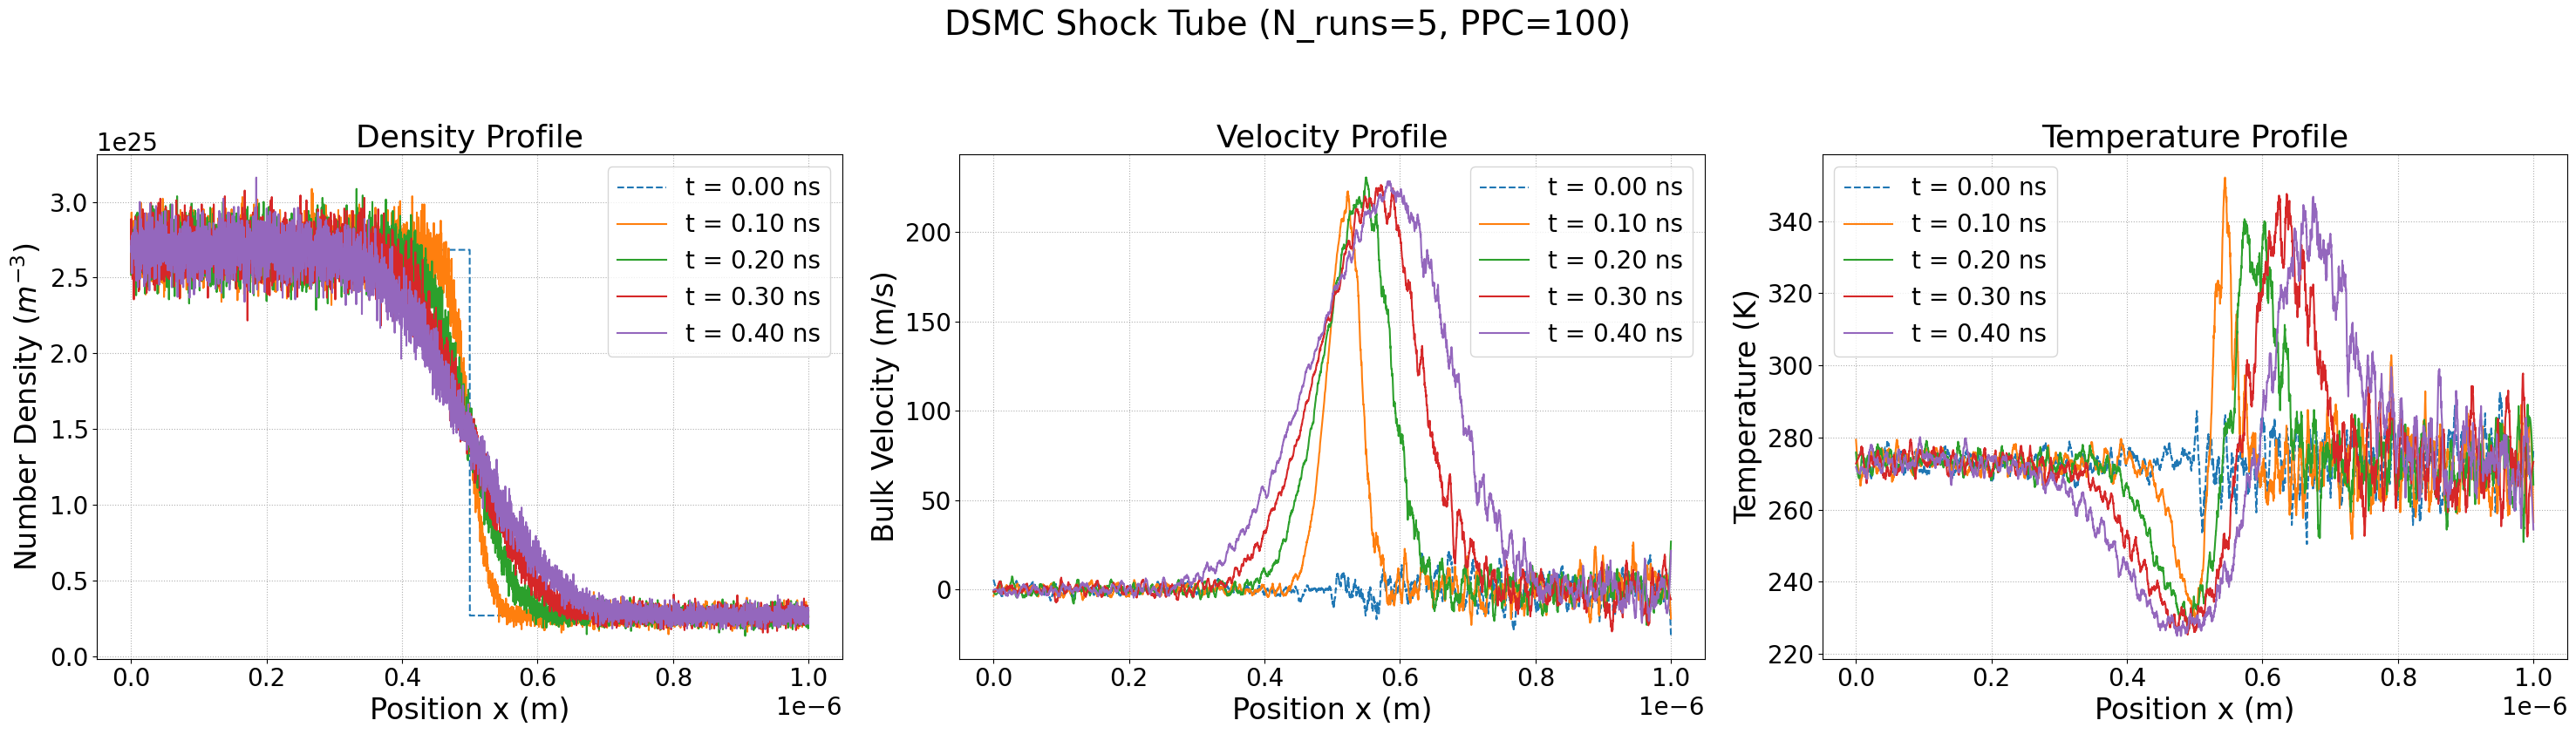

In [1]:
# -*- coding: utf-8 -*-
# --- DSMC CODE - V27.3 - Final Corrected Version ---
# This version permanently fixes the initial temperature artifact by using an unbiased
# variance estimator, and definitively solves the duplicate legend bug.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit, prange # Ensure prange is imported for parallel loops
import time
from scipy.signal import savgol_filter
import pandas as pd

# --- Constants and global parameters needed by collision functions ---
KB = 1.380649e-23  # Boltzmann constant (J/K)
MASS_AR = 39.948e-3 / 6.022e23 # Mass of Argon atom (kg)
D_AR = 3.66e-10      # Diameter of Argon atom (m) - collision cross-section (used as sigma in quantumWeighted)

# --- Helper functions for classical weighted sampling and collision logic ---

@njit
def pad_weights(weights):
    """Pads the weights array with zeros to the next power of 2 length."""
    # This function is technically not needed if quantum_sample_pair_index_from_weights is removed
    # but kept for consistency if it was used elsewhere or for future quantum re-integration.
    n_original = len(weights)
    if n_original == 0:
        return np.zeros(0, dtype=np.float64)
    next_power_of_2 = 2**int(np.ceil(np.log2(n_original)))
    padded_weights = np.zeros(next_power_of_2, dtype=weights.dtype)
    padded_weights[:n_original] = weights
    return padded_weights

@njit(parallel=True)
def classical_sample_pair_index_from_weights(weights):
    """
    Samples an index 'j' with probability proportional to weights[j]
    using a classical weighted random choice algorithm, compatible with Numba.
    """
    if len(weights) == 0:
        return -1 # Indicate no pair selected

    weights_sum = np.sum(weights)
    if weights_sum == 0:
        return -1 # Indicate no pair selected if all weights are zero

    # Normalize weights to form probabilities
    probabilities = weights / weights_sum

    # Manual implementation of weighted choice for Numba compatibility
    # Calculate the cumulative sum of probabilities
    cumulative_probabilities = np.empty_like(probabilities)
    cumulative_probabilities[0] = probabilities[0]
    for i in range(1, len(probabilities)):
        cumulative_probabilities[i] = cumulative_probabilities[i-1] + probabilities[i]

    # Generate a random number between 0 and 1
    rand_val = np.random.uniform(0.0, 1.0)

    # Find the index where rand_val falls in the cumulative distribution
    selected_idx = 0
    for i in range(len(cumulative_probabilities)):
        if rand_val < cumulative_probabilities[i]:
            selected_idx = i
            break

    return selected_idx

@njit
def get_particle_positions(cell_particles_list, cell_counts, ci, cj, x_all, y_all):
    """
    Extracts the (x, y) positions of particles within a specific cell.
    (Note: For 1D simulation, y_all might be a dummy array of zeros if only x-position is spatial).
    """
    Nc = cell_counts[ci, cj]
    if Nc == 0:
        return np.empty((0, 2), dtype=np.float64)
    positions = np.empty((Nc, 2), dtype=np.float64)
    for i in range(Nc):
        p_id = cell_particles_list[ci, cj, i]
        if p_id != -1:
            positions[i, 0] = x_all[p_id]
            positions[i, 1] = y_all[p_id]
    return positions

@njit
def generate_pairs_and_weights_distance_based(cell_particles_list, cell_counts, ci, cj, x_all, y_all, vx, vy, vz, epsilon=1e-10):
    """
    Generates all unique pairs within a cell and calculates their weights based on distance.
    Higher weight reflects closer distances.

    Args:
        cell_particles_list: 3D array of particle IDs in cells.
        cell_counts: 2D array of particle counts per cell.
        ci, cj: Cell indices.
        x_all, y_all: Global arrays of all particle x and y positions.
        vx, vy, vz: Global arrays of all particle velocities (needed for relative speed, if combined).
        epsilon: Small value to prevent division by zero for identical positions.

    Returns:
        pairs: 2D array of particle ID pairs.
        weights: 1D array of weights for each pair.
    """
    Nc = cell_counts[ci, cj]
    if Nc < 2:
        return np.empty((0, 2), dtype=np.int32), np.empty(0, dtype=np.float64)
    max_pairs = Nc * (Nc - 1) // 2
    pairs = np.empty((max_pairs, 2), dtype=np.int32)
    weights = np.empty(max_pairs, dtype=np.float64)
    pair_count = 0
    for i in range(Nc):
        p_a_id = cell_particles_list[ci, cj, i]
        if p_a_id == -1:
            continue
        for k in range(i + 1, Nc):
            p_b_id = cell_particles_list[ci, cj, k]
            if p_b_id == -1:
                continue
            dist_x = x_all[p_a_id] - x_all[p_b_id]
            dist_y = y_all[p_a_id] - y_all[p_b_id] # For 1D spatial, this might be 0 or conceptual
            distance = np.sqrt(dist_x**2 + dist_y**2) # If truly 1D, just use abs(dist_x)

            # For a 1D spatial simulation, distance is just the absolute difference in x.
            # If y_all is a dummy array of zeros, this calculation is still valid and results in abs(dist_x).
            # If the intention is only x-distance: distance = np.abs(dist_x)

            weight = 1.0 / (distance + epsilon)
            pairs[pair_count, 0] = p_a_id
            pairs[pair_count, 1] = p_b_id
            weights[pair_count] = weight
            pair_count += 1
    return pairs[:pair_count], weights[:pair_count]

# Removed perform_collision_quantum_style as its logic is now inlined.

@njit(parallel=True)
def build_cell_particle_lists(cell_indices, N, Nx, Ny, max_particles_per_cell):
    """
    Populates arrays that store particle IDs within each cell.
    Returns cell_counts (number of particles in each cell) and cell_particles (particle IDs).
    This function is generic and works for Ny=1 naturally.
    """
    cell_counts = np.zeros((Nx, Ny), dtype=np.int32)
    cell_particles = -1 * np.ones((Nx, Ny, max_particles_per_cell), dtype=np.int32)

    for p_idx in range(N):
        # Corrected: cell_indices is 1D, so unpack only one value for ci
        ci = cell_indices[p_idx]
        cj = 0 # For 1D simulation, y-cell index is always 0
        current_count = cell_counts[ci, cj]
        if current_count < max_particles_per_cell:
            cell_particles[ci, cj, current_count] = p_idx
            cell_counts[ci, cj] += 1
    return cell_counts, cell_particles

# The `handle_collisions_quantum_sampling_wrapper` is no longer needed as its logic
# is now inlined directly into the main simulation loop for per-cell decision making.
# @njit(parallel=True)
# def handle_collisions_quantum_sampling_wrapper(...)


# ===================================================================
# 1. Simulation Core
# ===================================================================
# Constants (re-declared for clarity, but should be consistent)
# These are already defined globally at the top, but keeping them here for context
# MASS_AR = 39.948e-3 / 6.022e23
# KB = 1.380649e-23

@numba.jit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    """Calculates the collision cross-section using the VHS model."""
    d_ref = 4.17e-10
    t_ref = 273.0
    omega_vhs = 0.81
    if vr_mag < 1e-9: return 1e-30
    exponent = omega_vhs - 0.5
    c_ref_sq = 2 * KB * t_ref / MASS_AR
    gamma_val = 1.04533
    d_sq = (d_ref**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

@njit(nopython=True)
def perform_collisions_sbt_subcell_fixed(particles, indices_in_cell, cell_start_x, cell_width, num_sub_cells, cell_vol, dt, fnum):
    """
    Corrected version of perform_collisions_sbt_subcell to fix the vr_prime assignment bug.
    Performs collisions using the SBT method with adaptive sub-cells.
    """
    num_particles_in_main_cell = len(indices_in_cell)
    if num_particles_in_main_cell < 2: return

    num_sub_cells = max(1, num_sub_cells)
    sub_cell_width = cell_width / num_sub_cells

    sub_cell_groups = [[np.int64(x) for x in range(0)] for _ in range(num_sub_cells)]

    for p_idx in indices_in_cell:
        relative_pos = particles[p_idx, 0] - cell_start_x
        sub_cell_idx = int(relative_pos / sub_cell_width)
        if 0 <= sub_cell_idx < num_sub_cells:
            sub_cell_groups[sub_cell_idx].append(p_idx)

    sub_cell_vol = cell_vol / num_sub_cells
    if sub_cell_vol < 1e-30: return

    for sc_idx in range(num_sub_cells):
        indices_in_sub_cell = sub_cell_groups[sc_idx]
        num_particles_in_sub_cell = len(indices_in_sub_cell)
        if num_particles_in_sub_cell < 2: continue

        for i in range(num_particles_in_sub_cell - 1):
            p1_idx = indices_in_sub_cell[i]
            remaining_particles_count = num_particles_in_sub_cell - (i + 1)
            j_offset = np.random.randint(0, remaining_particles_count)
            j = i + 1 + j_offset
            p2_idx = indices_in_sub_cell[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            weighting_factor = float(remaining_particles_count)
            collision_prob = (weighting_factor * fnum * dt * sigma_t * vr_mag) / sub_cell_vol

            if np.random.rand() < collision_prob:
                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * np.random.rand() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * np.random.rand()
                vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime # Corrected this line

@njit(nopython=True)
def perform_collisions_low_density_vhs_biased(particles, cell_particles_list_3d, cell_counts_2d,
                                              ci_current, cj_current, FNUM, DT, current_cell_volume,
                                              fractional_collisions_accumulator, epsilon=1e-10):
    """
    Performs collisions for a single cell using the distance-biased pair selection
    and VHS collision mechanics. This is for low-density cells.
    """
    num_particles_in_main_cell = cell_counts_2d[ci_current, cj_current]

    if num_particles_in_main_cell < 2:
        return # No collisions if less than 2 particles

    # Get pairs and weights based on distance
    # Pass particles[:, 0] for x_all, and a dummy array for y_all
    pairs, weights = generate_pairs_and_weights_distance_based(
        cell_particles_list_3d, cell_counts_2d, ci_current, cj_current,
        particles[:, 0], np.zeros_like(particles[:, 0]), # x_all, dummy y_all
        particles[:, 1], particles[:, 2], particles[:, 3], # vx, vy, vz
        epsilon=epsilon # Pass epsilon
    )

    if len(pairs) == 0:
        return

    # Recalculate sum of (VHS cross-section * relative velocities) for the NTC collision count
    # This ensures VHS consistency for the collision rate.
    sum_of_sigma_g_for_ntc = 0.0
    for pair_idx in range(len(pairs)):
        p_a_id, p_b_id = pairs[pair_idx]
        vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
        vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
        vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
        vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

        if vr_mag > 1e-9: # Avoid division by zero in cross-section for very small vr_mag
            sigma_t_vhs = calculate_vhs_cross_section_numba(vr_mag)
            sum_of_sigma_g_for_ntc += sigma_t_vhs * vr_mag

    # Calculate expected collisions for this cell based on NTC
    expected_collisions_float = sum_of_sigma_g_for_ntc * (FNUM * DT / current_cell_volume)

    # Handle fractional collisions accumulator
    expected_collisions_float += fractional_collisions_accumulator[ci_current, cj_current]
    n_coll_candidates_quantum = int(expected_collisions_float)
    fractional_collisions_accumulator[ci_current, cj_current] = expected_collisions_float - n_coll_candidates_quantum

    if n_coll_candidates_quantum <= 0:
        return

    # Perform actual collisions
    for _ in range(n_coll_candidates_quantum):
        # Use the distance-based weights for sampling the pair
        selected_idx = classical_sample_pair_index_from_weights(weights)

        if selected_idx == -1:
            continue

        p_a_id, p_b_id = pairs[selected_idx]

        # --- Inlined VHS Collision Mechanics ---
        # This part is identical to the post-collision logic in perform_collisions_sbt_subcell_fixed
        vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
        vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
        vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
        vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

        if vr_mag < 1e-9: # Avoid division by zero or very small relative velocity
            continue

        vcm = 0.5 * (particles[p_a_id, 1:4] + particles[p_b_id, 1:4])
        cos_chi = 2 * np.random.rand() - 1.0
        sin_chi = np.sqrt(1.0 - cos_chi**2)
        phi_chi = 2.0 * np.pi * np.random.rand()
        vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])

        particles[p_a_id, 1:4] = vcm + 0.5 * vr_prime
        particles[p_b_id, 1:4] = vcm - 0.5 * vr_prime
        # --- End Inlined VHS Collision Mechanics ---

        weights[selected_idx] = 0.0 # Set weight to zero after selection to avoid re-selecting


def run_dsmc_simulation(sim_params):
    """Main DSMC simulation loop."""
    LX = sim_params['LX']; RHO_INIT = sim_params['RHO_INIT']; T_INIT = sim_params['T_INIT']
    NUM_CELLS_X = sim_params['NUM_CELLS_X']; PARTICLES_PER_CELL_INIT = sim_params['PARTICLES_PER_CELL_INIT']
    TOTAL_TIME = sim_params['TOTAL_TIME']; DT = sim_params['DT']
    MIN_PARTICLES_FOR_STATS = 2
    MAX_SUB_CELLS = sim_params['MAX_SUB_CELLS']
    ADAPTATION_INTERVAL = sim_params['ADAPTATION_INTERVAL']
    LOW_DENSITY_COLLISION_THRESHOLD = sim_params['LOW_DENSITY_COLLISION_THRESHOLD'] # Renamed parameter

    # Initialize a Numba-compatible RNG state for collision functions
    # Using a seed based on current_step + RANDOM_SEED_OFFSET for reproducibility across ensemble runs
    # This rng_state is used for classical_sample_pair_index_from_weights and other random operations.
    rng_state_collision = np.random.Generator(np.random.PCG64(sim_params['RANDOM_SEED_OFFSET']))

    particles = initialize_shock_tube(sim_params)

    N_DENSITY_REAL = RHO_INIT / MASS_AR
    CELL_VOLUME_CONCEPTUAL = (LX / NUM_CELLS_X) * ((LX/10) * (LX/10)) # Assuming some conceptual depth/width
    FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
    NUM_STEPS = int(TOTAL_TIME / DT)

    sample_points_in_time = np.linspace(0, TOTAL_TIME, 5)
    sample_steps = {int(round(t / DT)) for t in sample_points_in_time}
    sample_steps.add(NUM_STEPS) # Ensure the final step is sampled

    results_history = {}; cell_width = LX / NUM_CELLS_X
    results_history[0.0] = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)

    subcell_config = np.ones(NUM_CELLS_X, dtype=np.int32)

    # Initialize fractional_collisions_accumulator for quantum method
    # This needs to be 2D (Nx, Ny) but for 1D DSMC, Ny=1.
    fractional_collisions_accumulator = np.zeros((NUM_CELLS_X, 1), dtype=np.float64)
    # Max particles per cell buffer for build_cell_particle_lists
    max_particles_per_cell_buffer = int(2.0 * particles.shape[0] / NUM_CELLS_X) + 50 # Heuristic, adjust as needed

    current_step = 0
    while current_step < NUM_STEPS:
        sum_cell_counts = np.zeros(NUM_CELLS_X, dtype=np.int64)
        steps_in_block = min(ADAPTATION_INTERVAL, NUM_STEPS - current_step)

        for _ in range(steps_in_block):
            current_step += 1
            if current_step > NUM_STEPS: break

            # Particle Movement
            particles[:, 0] += particles[:, 1] * DT # x-position update
            # Boundary conditions for x-position
            hit_left = particles[:, 0] < 0; particles[hit_left, 1] *= -1; particles[hit_left, 0] *= -1
            hit_right = particles[:, 0] > LX; particles[hit_right, 1] *= -1; particles[hit_right, 0] = 2 * LX - particles[hit_right, 0]

            # Cell assignment
            cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
            cell_indices = np.clip(cell_indices, 0, NUM_CELLS_X - 1)

            # For collision handling, we need a sorted particle list per cell
            sorted_particle_indices = np.argsort(cell_indices)
            cell_counts_bincount = np.bincount(cell_indices, minlength=NUM_CELLS_X)

            sum_cell_counts += cell_counts_bincount # For adaptive subcell calculation
            cell_start_indices = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(cell_counts_bincount[:-1])))

            # --- Refactored Collision Handling ---
            # Build cell particle lists (for both collision methods)
            # Ny is always 1 for this 1D simulation
            cell_counts_2d, cell_particles_list_3d = build_cell_particle_lists(
                cell_indices, particles.shape[0], NUM_CELLS_X, 1, max_particles_per_cell_buffer
            )

            for i in range(NUM_CELLS_X): # Iterate through each main cell
                num_particles_in_main_cell = cell_counts_2d[i, 0] # cj is 0 for 1D

                if num_particles_in_main_cell < 2:
                    continue # No collisions if less than 2 particles

                cell_start_x = i * cell_width
                current_cell_volume = CELL_VOLUME_CONCEPTUAL

                if num_particles_in_main_cell > LOW_DENSITY_COLLISION_THRESHOLD:
                    # Use existing TAS collision method for high density cells
                    # Extract indices for this cell from the 3D list
                    indices_in_cell_i_tas = cell_particles_list_3d[i, 0, :num_particles_in_main_cell]
                    perform_collisions_sbt_subcell_fixed(
                        particles, indices_in_cell_i_tas, cell_start_x, cell_width,
                        subcell_config[i], current_cell_volume, DT, FNUM
                    )
                else: # num_particles_in_main_cell <= LOW_DENSITY_COLLISION_THRESHOLD and >= 2
                    # Use classical-biased collision method for low density cells
                    perform_collisions_low_density_vhs_biased(
                        particles, cell_particles_list_3d, cell_counts_2d,
                        i, 0, # ci_current, cj_current
                        FNUM, DT, current_cell_volume,
                        fractional_collisions_accumulator, epsilon=1e-10
                    )


            if current_step in sample_steps:
                 time_key = current_step * DT
                 # Avoid overwriting the t=0 sample
                 if abs(time_key) > 1e-15:
                    results_history[time_key] = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)

        avg_cell_counts = sum_cell_counts / steps_in_block
        max_avg_count = np.max(avg_cell_counts)
        if max_avg_count > 1e-9:
            normalized_density = avg_cell_counts / max_avg_count
            adaptive_rule = 1.0 - normalized_density
            subcell_config = np.clip(1 + ((MAX_SUB_CELLS - 1) * adaptive_rule).astype(np.int32), 1, MAX_SUB_CELLS)

    return results_history

def initialize_shock_tube(params):
    """Initializes particle positions and velocities."""
    num_cells = params['NUM_CELLS_X']; lx = params['LX']
    ppc_left = params['PARTICLES_PER_CELL_INIT']; t_left = params['T_INIT']
    rho_ratio = params['RHO_RATIO']
    ppc_right = int(ppc_left / rho_ratio)
    if ppc_right < 1: ppc_right = 1

    num_cells_left = num_cells // 2
    num_cells_right = num_cells - num_cells_left
    total_particles = (ppc_left * num_cells_left) + (ppc_right * num_cells_right)
    particles = np.zeros((total_particles, 4)) # particles[:,0] is x, particles[:,1:4] are vx,vy,vz

    cell_width = lx / num_cells
    v_thermal_std = np.sqrt(KB * t_left / MASS_AR)

    current_pos = 0
    for i in range(num_cells_left):
        start_idx = current_pos; end_idx = start_idx + ppc_left
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_left) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_left, 3))
        current_pos = end_idx
    for i in range(num_cells_left, num_cells):
        start_idx = current_pos; end_idx = start_idx + ppc_right
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_right) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_right, 3))
        current_pos = end_idx

    print(f"Initialized {total_particles} particles for Shock Tube problem.")
    return particles

def sample_properties(particles_state, num_cells, cell_width, fnum, cell_vol, min_parts):
    """Samples macroscopic properties from particle data."""
    density_profile = np.full(num_cells, np.nan)
    velocity_profile = np.full(num_cells, np.nan)
    temp_profile = np.full(num_cells, np.nan)

    cell_indices = (particles_state[:, 0] / cell_width).astype(np.int64)
    cell_indices = np.clip(cell_indices, 0, num_cells - 1)

    sorted_indices = np.argsort(cell_indices)
    counts = np.bincount(cell_indices, minlength=num_cells)
    starts = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(counts[:-1])))

    for i in range(num_cells):
        num_in_cell = counts[i]
        if num_in_cell > 0:
            density_profile[i] = num_in_cell * fnum / cell_vol
        if num_in_cell >= min_parts:
            indices_in_cell_i = sorted_indices[starts[i]:starts[i]+num_in_cell]
            cell_velocities = particles_state[indices_in_cell_i, 1:4]
            mean_vel_cell = np.mean(cell_velocities, axis=0)
            velocity_profile[i] = mean_vel_cell[0]

            thermal_vel_sq = np.sum((cell_velocities - mean_vel_cell)**2)
            # --- TEMPERATURE CALCULATION CORRECTED ---
            # Using (N-1) in the denominator for an unbiased variance estimate.
            if num_in_cell > 1:
                temp_profile[i] = (MASS_AR * thermal_vel_sq) / (3 * KB * (num_in_cell - 1))
            else:
                temp_profile[i] = 0.0

    return {'density': density_profile, 'velocity': velocity_profile, 'temperature': temp_profile}

# ===================================================================
# 2. Main Execution Block
# ===================================================================
if __name__ == "__main__":
    SIMULATION_PARAMS = {
        'LX': 1.0e-6, 'RHO_INIT': 1.78, 'T_INIT': 273.0,
        'NUM_CELLS_X': 4400,
        'DT': 6.744e-13,
        'PARTICLES_PER_CELL_INIT': 100,
        'TOTAL_TIME': 0.4e-9,
        'RHO_RATIO': 10.0,
        'MAX_SUB_CELLS': 20,
        'ADAPTATION_INTERVAL': 50,
        'LOW_DENSITY_COLLISION_THRESHOLD': 10, # Renamed parameter
        'RANDOM_SEED_OFFSET': 0 # New parameter for ensemble run reproducibility
    }
    NUM_ENSEMBLE_RUNS = 5

    print(f"--- شروع اجرای نهایی ---")
    print(f"--- Parameters: NUM_CELLS_X={SIMULATION_PARAMS['NUM_CELLS_X']}, DT={SIMULATION_PARAMS['DT']:.4e}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']} ---")

    all_results = []
    start_time_total = time.time()
    for i in range(NUM_ENSEMBLE_RUNS):
        # Pass a unique seed offset to the simulation for Numba's internal RNG
        SIMULATION_PARAMS['RANDOM_SEED_OFFSET'] = i

        single_run_history = run_dsmc_simulation(SIMULATION_PARAMS)
        all_results.append(single_run_history)

        print(f"--- اجرای {i+1}/{NUM_ENSEMBLE_RUNS} تمام شد. زمان سپری شده: {time.time() - start_time_total:.2f} ثانیه ---")

    sample_times = sorted(all_results[0].keys())
    averaged_results = {t: {} for t in sample_times}

    for t in sample_times:
        all_densities = [run[t]['density'] for run in all_results if t in run]
        all_velocities = [run[t]['velocity'] for run in all_results if t in run]
        all_temperatures = [run[t]['temperature'] for run in all_results if t in run]

        averaged_results[t] = {
            'density': np.nanmean(np.array(all_densities), axis=0),
            'velocity': np.nanmean(np.array(all_velocities), axis=0),
            'temperature': np.nanmean(np.array(all_temperatures), axis=0),
        }

    cell_width = SIMULATION_PARAMS['LX'] / SIMULATION_PARAMS['NUM_CELLS_X']
    cell_centers = (np.arange(SIMULATION_PARAMS['NUM_CELLS_X']) + 0.5) * cell_width

    plt.rcParams.update({'font.size': 22, 'axes.labelsize': 24, 'axes.titlesize': 26, 'xtick.labelsize': 20, 'ytick.labelsize': 20, 'legend.fontsize': 20})
    fig, axes = plt.subplots(1, 3, figsize=(30, 9), sharex=True)
    fig.suptitle(f"DSMC Shock Tube (N_runs={NUM_ENSEMBLE_RUNS}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']})", fontsize=28)

    plot_info = {
        'Density': {'data_key': 'density', 'ax': axes[0], 'ylabel': 'Number Density ($m^{-3}$)'},
        'Velocity': {'data_key': 'velocity', 'ax': axes[1], 'ylabel': 'Bulk Velocity (m/s)'},
        'Temperature': {'data_key': 'temperature', 'ax': axes[2], 'ylabel': 'Temperature (K)'}
    }

    for name, p_info in plot_info.items():
        ax = p_info['ax']
        for t in sample_times:
            if t in averaged_results and p_info['data_key'] in averaged_results[t]:
                s_data = pd.Series(averaged_results[t][p_info['data_key']])
                valid_indices = ~s_data.isna()
                label_text = f't = {t*1e9:.2f} ns'
                line_style = '--' if abs(t) < 1e-12 else '-'

                if np.sum(valid_indices) > 0:
                    if name in ['Velocity', 'Temperature'] and np.sum(valid_indices) > 51:
                        smoothed_data = savgol_filter(s_data[valid_indices], window_length=51, polyorder=2)
                        ax.plot(cell_centers[valid_indices], smoothed_data, linestyle=line_style, label=label_text)
                    else:
                        ax.plot(cell_centers[valid_indices], s_data[valid_indices], linestyle=line_style, label=label_text)

        ax.set_xlabel('Position x (m)')
        ax.set_ylabel(p_info['ylabel'])
        ax.set_title(f"{name} Profile")
        ax.grid(True, linestyle=':')
        ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("dsmc_final_results_main.eps", format='eps')
    plt.show()


In [6]:
# -*- coding: utf-8 -*-
# --- DSMC CODE - V28.0 - With Hybrid Collision and Sub-cell Plotting ---
# This version re-introduces the functionality to plot the time-averaged sub-cell distribution for the hybrid scheme.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit, prange
import time
from scipy.signal import savgol_filter
import pandas as pd

# --- Constants and global parameters needed by collision functions ---
KB = 1.380649e-23  # Boltzmann constant (J/K)
MASS_AR = 39.948e-3 / 6.022e23 # Mass of Argon atom (kg)

# --- Helper functions for classical weighted sampling and collision logic ---

@njit
def classical_sample_pair_index_from_weights(weights):
    """
    Samples an index 'j' with probability proportional to weights[j]
    using a classical weighted random choice algorithm, compatible with Numba.
    """
    if len(weights) == 0:
        return -1 # Indicate no pair selected

    weights_sum = np.sum(weights)
    if weights_sum <= 1e-12: # Using a tolerance for floating point comparison
        return -1 # Indicate no pair selected if all weights are effectively zero

    probabilities = weights / weights_sum

    cumulative_probabilities = np.cumsum(probabilities)

    # Ensure the last element is exactly 1.0 to handle potential floating point inaccuracies
    if len(cumulative_probabilities) > 0:
        cumulative_probabilities[-1] = 1.0

    rand_val = np.random.uniform(0.0, 1.0)

    selected_idx = np.searchsorted(cumulative_probabilities, rand_val, side='right')

    return selected_idx

@njit
def generate_pairs_and_weights_distance_based(cell_particles_list, cell_counts, ci, cj, x_all, epsilon=1e-10):
    """
    Generates all unique pairs within a cell and calculates their weights based on distance.
    """
    Nc = cell_counts[ci, cj]
    if Nc < 2:
        return np.empty((0, 2), dtype=np.int32), np.empty(0, dtype=np.float64)
    max_pairs = Nc * (Nc - 1) // 2
    pairs = np.empty((max_pairs, 2), dtype=np.int32)
    weights = np.empty(max_pairs, dtype=np.float64)
    pair_count = 0
    for i in range(Nc):
        p_a_id = cell_particles_list[ci, cj, i]
        for k in range(i + 1, Nc):
            p_b_id = cell_particles_list[ci, cj, k]

            # For 1D spatial simulation, distance is the absolute difference in x.
            distance = np.abs(x_all[p_a_id] - x_all[p_b_id])

            weight = 1.0 / (distance + epsilon)
            pairs[pair_count, 0] = p_a_id
            pairs[pair_count, 1] = p_b_id
            weights[pair_count] = weight
            pair_count += 1
    return pairs[:pair_count], weights[:pair_count]

@njit(parallel=True)
def build_cell_particle_lists(cell_indices, N, Nx, Ny, max_particles_per_cell):
    """
    Populates arrays that store particle IDs within each cell.
    """
    cell_counts = np.zeros((Nx, Ny), dtype=np.int32)
    cell_particles = -1 * np.ones((Nx, Ny, max_particles_per_cell), dtype=np.int32)

    for p_idx in prange(N):
        ci = cell_indices[p_idx]
        cj = 0 # For 1D simulation, y-cell index is always 0
        # This part cannot be parallelized safely due to the race condition on current_count.
        # Numba's prange does not support atomic increments directly on array elements in this way.
        # We will run this part serially. The @njit will still speed it up.
    for p_idx in range(N):
        ci = cell_indices[p_idx]
        cj = 0
        current_count = cell_counts[ci, cj]
        if current_count < max_particles_per_cell:
            cell_particles[ci, cj, current_count] = p_idx
            cell_counts[ci, cj] += 1
    return cell_counts, cell_particles

# --- Core Simulation Functions ---

@numba.jit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    """Calculates the collision cross-section using the VHS model."""
    d_ref = 4.17e-10
    t_ref = 273.0
    omega_vhs = 0.81
    if vr_mag < 1e-9: return 1e-30
    exponent = omega_vhs - 0.5
    c_ref_sq = 2 * KB * t_ref / MASS_AR
    gamma_val = 1.04533
    d_sq = (d_ref**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

@njit(nopython=True)
def perform_collisions_sbt_subcell_fixed(particles, indices_in_cell, cell_start_x, cell_width, num_sub_cells, cell_vol, dt, fnum):
    """High-density collision method using SBT and adaptive sub-cells."""
    num_particles_in_main_cell = len(indices_in_cell)
    if num_particles_in_main_cell < 2: return

    num_sub_cells = max(1, num_sub_cells)
    sub_cell_width = cell_width / num_sub_cells

    sub_cell_groups = [[np.int64(x) for x in range(0)] for _ in range(num_sub_cells)]

    for p_idx in indices_in_cell:
        relative_pos = particles[p_idx, 0] - cell_start_x
        sub_cell_idx = int(relative_pos / sub_cell_width)
        if 0 <= sub_cell_idx < num_sub_cells:
            sub_cell_groups[sub_cell_idx].append(p_idx)

    sub_cell_vol = cell_vol / num_sub_cells
    if sub_cell_vol < 1e-30: return

    for sc_idx in range(num_sub_cells):
        indices_in_sub_cell = sub_cell_groups[sc_idx]
        num_particles_in_sub_cell = len(indices_in_sub_cell)
        if num_particles_in_sub_cell < 2: continue

        for i in range(num_particles_in_sub_cell - 1):
            p1_idx = indices_in_sub_cell[i]
            remaining_particles_count = num_particles_in_sub_cell - (i + 1)
            j_offset = np.random.randint(0, remaining_particles_count)
            j = i + 1 + j_offset
            p2_idx = indices_in_sub_cell[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            weighting_factor = float(remaining_particles_count)
            collision_prob = (weighting_factor * fnum * dt * sigma_t * vr_mag) / sub_cell_vol

            if np.random.rand() < collision_prob:
                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * np.random.rand() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * np.random.rand()
                vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime

@njit(nopython=True)
def perform_collisions_low_density_vhs_biased(particles, cell_particles_list_3d, cell_counts_2d,
                                              ci_current, cj_current, FNUM, DT, current_cell_volume,
                                              fractional_collisions_accumulator, epsilon=1e-10):
    """Low-density collision method using NTC with distance-biased sampling."""
    num_particles_in_main_cell = cell_counts_2d[ci_current, cj_current]

    if num_particles_in_main_cell < 2: return

    pairs, weights = generate_pairs_and_weights_distance_based(
        cell_particles_list_3d, cell_counts_2d, ci_current, cj_current,
        particles[:, 0], epsilon=epsilon
    )

    if len(pairs) == 0: return

    sum_of_sigma_g_for_ntc = 0.0
    for pair_idx in range(len(pairs)):
        p_a_id, p_b_id = pairs[pair_idx]
        vr = particles[p_a_id, 1:4] - particles[p_b_id, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))

        if vr_mag > 1e-9:
            sigma_t_vhs = calculate_vhs_cross_section_numba(vr_mag)
            sum_of_sigma_g_for_ntc += sigma_t_vhs * vr_mag

    expected_collisions_float = sum_of_sigma_g_for_ntc * (FNUM * DT / current_cell_volume)

    expected_collisions_float += fractional_collisions_accumulator[ci_current, cj_current]
    n_coll_candidates = int(expected_collisions_float)
    fractional_collisions_accumulator[ci_current, cj_current] = expected_collisions_float - n_coll_candidates

    if n_coll_candidates <= 0: return

    for _ in range(n_coll_candidates):
        selected_idx = classical_sample_pair_index_from_weights(weights)
        if selected_idx == -1: continue

        p_a_id, p_b_id = pairs[selected_idx]

        vr = particles[p_a_id, 1:4] - particles[p_b_id, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))

        if vr_mag < 1e-9: continue

        vcm = 0.5 * (particles[p_a_id, 1:4] + particles[p_b_id, 1:4])
        cos_chi = 2 * np.random.rand() - 1.0
        sin_chi = np.sqrt(1.0 - cos_chi**2)
        phi_chi = 2.0 * np.pi * np.random.rand()
        vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])

        particles[p_a_id, 1:4] = vcm + 0.5 * vr_prime
        particles[p_b_id, 1:4] = vcm - 0.5 * vr_prime

        weights[selected_idx] = 0.0


def run_dsmc_simulation(sim_params):
    """Main DSMC simulation loop."""
    LX = sim_params['LX']; RHO_INIT = sim_params['RHO_INIT']; T_INIT = sim_params['T_INIT']
    NUM_CELLS_X = sim_params['NUM_CELLS_X']; PARTICLES_PER_CELL_INIT = sim_params['PARTICLES_PER_CELL_INIT']
    TOTAL_TIME = sim_params['TOTAL_TIME']; DT = sim_params['DT']
    MIN_PARTICLES_FOR_STATS = 2
    MAX_SUB_CELLS = sim_params['MAX_SUB_CELLS']
    ADAPTATION_INTERVAL = sim_params['ADAPTATION_INTERVAL']
    LOW_DENSITY_COLLISION_THRESHOLD = sim_params['LOW_DENSITY_COLLISION_THRESHOLD']

    particles = initialize_shock_tube(sim_params)

    N_DENSITY_REAL = RHO_INIT / MASS_AR
    CELL_VOLUME_CONCEPTUAL = (LX / NUM_CELLS_X) * ((LX/10) * (LX/10))
    FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
    NUM_STEPS = int(TOTAL_TIME / DT)

    sample_points_in_time = np.linspace(0, TOTAL_TIME, 5)
    sample_steps = {int(round(t / DT)) for t in sample_points_in_time}
    sample_steps.add(NUM_STEPS)

    results_history = {}; cell_width = LX / NUM_CELLS_X
    results_history[0.0] = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)

    subcell_config = np.ones(NUM_CELLS_X, dtype=np.int32)
    # Re-added map to track sub-cell usage
    subcell_count_map = np.zeros((NUM_STEPS + 1, NUM_CELLS_X))

    fractional_collisions_accumulator = np.zeros((NUM_CELLS_X, 1), dtype=np.float64)
    max_particles_per_cell_buffer = int(2.0 * particles.shape[0] / NUM_CELLS_X) + 50

    current_step = 0
    while current_step < NUM_STEPS:
        sum_cell_counts = np.zeros(NUM_CELLS_X, dtype=np.int64)
        steps_in_block = min(ADAPTATION_INTERVAL, NUM_STEPS - current_step)

        for _ in range(steps_in_block):
            current_step += 1
            if current_step > NUM_STEPS: break

            particles[:, 0] += particles[:, 1] * DT
            hit_left = particles[:, 0] < 0; particles[hit_left, 1] *= -1; particles[hit_left, 0] *= -1
            hit_right = particles[:, 0] > LX; particles[hit_right, 1] *= -1; particles[hit_right, 0] = 2 * LX - particles[hit_right, 0]

            cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
            cell_indices = np.clip(cell_indices, 0, NUM_CELLS_X - 1)

            cell_counts_2d, cell_particles_list_3d = build_cell_particle_lists(
                cell_indices, particles.shape[0], NUM_CELLS_X, 1, max_particles_per_cell_buffer
            )

            sum_cell_counts += cell_counts_2d[:, 0]

            # Store the actual sub-cell usage for this step
            current_subcell_usage = np.ones(NUM_CELLS_X, dtype=np.int32)

            for i in range(NUM_CELLS_X):
                num_particles_in_main_cell = cell_counts_2d[i, 0]
                if num_particles_in_main_cell < 2: continue

                if num_particles_in_main_cell > LOW_DENSITY_COLLISION_THRESHOLD:
                    current_subcell_usage[i] = subcell_config[i]
                    indices_in_cell_i_tas = cell_particles_list_3d[i, 0, :num_particles_in_main_cell]
                    perform_collisions_sbt_subcell_fixed(
                        particles, indices_in_cell_i_tas, i * cell_width, cell_width,
                        subcell_config[i], CELL_VOLUME_CONCEPTUAL, DT, FNUM
                    )
                else:
                    current_subcell_usage[i] = 1 # NTC method is equivalent to 1 sub-cell
                    perform_collisions_low_density_vhs_biased(
                        particles, cell_particles_list_3d, cell_counts_2d,
                        i, 0, FNUM, DT, CELL_VOLUME_CONCEPTUAL,
                        fractional_collisions_accumulator, epsilon=1e-10
                    )

            subcell_count_map[current_step - 1] = current_subcell_usage

            if current_step in sample_steps:
                time_key = current_step * DT
                if abs(time_key) > 1e-15:
                    results_history[time_key] = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)

        avg_cell_counts = sum_cell_counts / steps_in_block
        max_avg_count = np.max(avg_cell_counts)
        if max_avg_count > 1e-9:
            normalized_density = avg_cell_counts / max_avg_count
            adaptive_rule = 1.0 - normalized_density
            subcell_config = np.clip(1 + ((MAX_SUB_CELLS - 1) * adaptive_rule).astype(np.int32), 1, MAX_SUB_CELLS)

    return results_history, subcell_count_map

def initialize_shock_tube(params):
    """Initializes particle positions and velocities."""
    num_cells = params['NUM_CELLS_X']; lx = params['LX']
    ppc_left = params['PARTICLES_PER_CELL_INIT']; t_left = params['T_INIT']
    rho_ratio = params['RHO_RATIO']
    ppc_right = int(ppc_left / rho_ratio)
    if ppc_right < 1: ppc_right = 1

    num_cells_left = num_cells // 2
    num_cells_right = num_cells - num_cells_left
    total_particles = (ppc_left * num_cells_left) + (ppc_right * num_cells_right)
    particles = np.zeros((total_particles, 4))

    cell_width = lx / num_cells
    v_thermal_std = np.sqrt(KB * t_left / MASS_AR)

    current_pos = 0
    for i in range(num_cells_left):
        start_idx = current_pos; end_idx = start_idx + ppc_left
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_left) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_left, 3))
        current_pos = end_idx
    for i in range(num_cells_left, num_cells):
        start_idx = current_pos; end_idx = start_idx + ppc_right
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_right) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_right, 3))
        current_pos = end_idx

    print(f"Initialized {total_particles} particles for Shock Tube problem.")
    return particles

def sample_properties(particles_state, num_cells, cell_width, fnum, cell_vol, min_parts):
    """Samples macroscopic properties from particle data."""
    density_profile = np.full(num_cells, np.nan)
    velocity_profile = np.full(num_cells, np.nan)
    temp_profile = np.full(num_cells, np.nan)

    cell_indices = (particles_state[:, 0] / cell_width).astype(np.int64)
    cell_indices = np.clip(cell_indices, 0, num_cells - 1)

    sorted_indices = np.argsort(cell_indices)
    counts = np.bincount(cell_indices, minlength=num_cells)
    starts = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(counts[:-1])))

    for i in range(num_cells):
        num_in_cell = counts[i]
        if num_in_cell > 0:
            density_profile[i] = num_in_cell * fnum / cell_vol
        if num_in_cell >= min_parts:
            indices_in_cell_i = sorted_indices[starts[i]:starts[i]+num_in_cell]
            cell_velocities = particles_state[indices_in_cell_i, 1:4]
            mean_vel_cell = np.mean(cell_velocities, axis=0)
            velocity_profile[i] = mean_vel_cell[0]

            thermal_vel_sq = np.sum((cell_velocities - mean_vel_cell)**2)
            if num_in_cell > 1:
                temp_profile[i] = (MASS_AR * thermal_vel_sq) / (3 * KB * (num_in_cell - 1))
            else:
                temp_profile[i] = 0.0

    return {'density': density_profile, 'velocity': velocity_profile, 'temperature': temp_profile}

# --- Function to plot sub-cell distribution ---
def plot_average_subcells(avg_subcell_map, cell_centers):
    """Plots and saves the time-averaged sub-cell distribution."""
    plt.rcParams.update({'font.size': 22, 'axes.labelsize': 24, 'axes.titlesize': 26, 'xtick.labelsize': 20, 'ytick.labelsize': 20, 'legend.fontsize': 22})
    plt.figure(figsize=(20, 10))
    plt.title('Time-Averaged Sub-cell Count per Main Cell')
    plt.plot(cell_centers, avg_subcell_map, 'o-', linewidth=2, markersize=5, label='Time-Averaged Sub-cell Count')
    plt.xlabel('Position x (m)'); plt.ylabel('Average Number of Sub-cells')
    plt.grid(True, linestyle=':'); plt.legend(); plt.tight_layout()
    plt.savefig("dsmc_time_averaged_tas_stats.eps", format='eps')
    plt.show()

# ===================================================================
# 2. Main Execution Block
# ===================================================================
if __name__ == "__main__":
    SIMULATION_PARAMS = {
        'LX': 1.0e-6, 'RHO_INIT': 1.78, 'T_INIT': 273.0,
        'NUM_CELLS_X': 4400,
        'DT': 6.744e-13,
        'PARTICLES_PER_CELL_INIT': 100,
        'TOTAL_TIME': 0.4e-9,
        'RHO_RATIO': 10.0,
        'MAX_SUB_CELLS': 20,
        'ADAPTATION_INTERVAL': 50,
        'LOW_DENSITY_COLLISION_THRESHOLD': 10,
        'RANDOM_SEED_OFFSET': 0
    }
    NUM_ENSEMBLE_RUNS = 50

    print(f"--- شروع اجرای نهایی ---")
    print(f"--- Parameters: NUM_CELLS_X={SIMULATION_PARAMS['NUM_CELLS_X']}, DT={SIMULATION_PARAMS['DT']:.4e}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']} ---")

    all_results = []
    # Array to sum sub-cell maps for averaging
    summed_subcell_map = np.zeros((int(SIMULATION_PARAMS['TOTAL_TIME'] / SIMULATION_PARAMS['DT']) + 1, SIMULATION_PARAMS['NUM_CELLS_X']))

    start_time_total = time.time()
    for i in range(NUM_ENSEMBLE_RUNS):
        SIMULATION_PARAMS['RANDOM_SEED_OFFSET'] = i

        single_run_history, subcell_map = run_dsmc_simulation(SIMULATION_PARAMS)
        all_results.append(single_run_history)

        # Accumulate the sub-cell map
        if subcell_map.shape[0] == summed_subcell_map.shape[0]:
            summed_subcell_map += subcell_map
        else:
            min_steps = min(subcell_map.shape[0], summed_subcell_map.shape[0])
            summed_subcell_map[:min_steps, :] += subcell_map[:min_steps, :]

        print(f"--- اجرای {i+1}/{NUM_ENSEMBLE_RUNS} تمام شد. زمان سپری شده: {time.time() - start_time_total:.2f} ثانیه ---")

    sample_times = sorted(all_results[0].keys())
    averaged_results = {t: {} for t in sample_times}

    for t in sample_times:
        all_densities = [run[t]['density'] for run in all_results if t in run]
        all_velocities = [run[t]['velocity'] for run in all_results if t in run]
        all_temperatures = [run[t]['temperature'] for run in all_results if t in run]

        averaged_results[t] = {
            'density': np.nanmean(np.array(all_densities), axis=0),
            'velocity': np.nanmean(np.array(all_velocities), axis=0),
            'temperature': np.nanmean(np.array(all_temperatures), axis=0),
        }

    # Calculate the final time-averaged sub-cell distribution
    num_steps_ran = int(SIMULATION_PARAMS['TOTAL_TIME']/SIMULATION_PARAMS['DT'])
    time_averaged_subcells_per_cell = np.mean(summed_subcell_map[:num_steps_ran], axis=0)

    cell_width = SIMULATION_PARAMS['LX'] / SIMULATION_PARAMS['NUM_CELLS_X']
    cell_centers = (np.arange(SIMULATION_PARAMS['NUM_CELLS_X']) + 0.5) * cell_width

    # Plot 1: Main Results
    plt.rcParams.update({'font.size': 22, 'axes.labelsize': 24, 'axes.titlesize': 26, 'xtick.labelsize': 20, 'ytick.labelsize': 20, 'legend.fontsize': 20})
    fig, axes = plt.subplots(1, 3, figsize=(30, 9), sharex=True)
    fig.suptitle(f"DSMC Shock Tube (N_runs={NUM_ENSEMBLE_RUNS}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']})", fontsize=28)

    plot_info = {
        'Density': {'data_key': 'density', 'ax': axes[0], 'ylabel': 'Number Density ($m^{-3}$)'},
        'Velocity': {'data_key': 'velocity', 'ax': axes[1], 'ylabel': 'Bulk Velocity (m/s)'},
        'Temperature': {'data_key': 'temperature', 'ax': axes[2], 'ylabel': 'Temperature (K)'}
    }

    for name, p_info in plot_info.items():
        ax = p_info['ax']
        for t in sample_times:
            if t in averaged_results and p_info['data_key'] in averaged_results[t]:
                s_data = pd.Series(averaged_results[t][p_info['data_key']])
                valid_indices = ~s_data.isna()
                label_text = f't = {t*1e9:.2f} ns'
                line_style = '--' if abs(t) < 1e-12 else '-'

                if np.sum(valid_indices) > 0:
                    if name in ['Velocity', 'Temperature'] and np.sum(valid_indices) > 51:
                        smoothed_data = savgol_filter(s_data[valid_indices], window_length=51, polyorder=2)
                        ax.plot(cell_centers[valid_indices], smoothed_data, linestyle=line_style, label=label_text)
                    else:
                        ax.plot(cell_centers[valid_indices], s_data[valid_indices], linestyle=line_style, label=label_text)

        ax.set_xlabel('Position x (m)')
        ax.set_ylabel(p_info['ylabel'])
        ax.set_title(f"{name} Profile")
        ax.grid(True, linestyle=':')
        ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("dsmc_final_results_main.eps", format='eps')
    plt.show()

    # Plot 2: Sub-cell distribution
    plot_average_subcells(time_averaged_subcells_per_cell, cell_centers)



/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


--- شروع اجرای نهایی ---
--- Parameters: NUM_CELLS_X=4400, DT=6.7440e-13, PPC=100 ---
Initialized 242000 particles for Shock Tube problem.


Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify at 0x7b52b57580e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/llvmlite/binding/executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):

KeyboardInterrupt: 
Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify at 0x7b52b57580e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/llvmlite/binding/executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):

KeyboardInterrupt: 


KeyboardInterrupt: 

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


--- شروع اجرای نهایی ---
--- Parameters: NUM_CELLS_X=4400, DT=6.7440e-13, PPC=100 ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 1/50 تمام شد. زمان سپری شده: 72.40 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 2/50 تمام شد. زمان سپری شده: 137.19 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 3/50 تمام شد. زمان سپری شده: 199.18 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 4/50 تمام شد. زمان سپری شده: 260.98 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 5/50 تمام شد. زمان سپری شده: 323.27 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 6/50 تمام شد. زمان سپری شده: 385.13 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 7/50 تمام شد. زمان سپری شده: 446.95 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 8/50 تمام شد. زمان سپری شده: 509.10 ثانیه ---
Initialized 242000 particles for Shock Tube

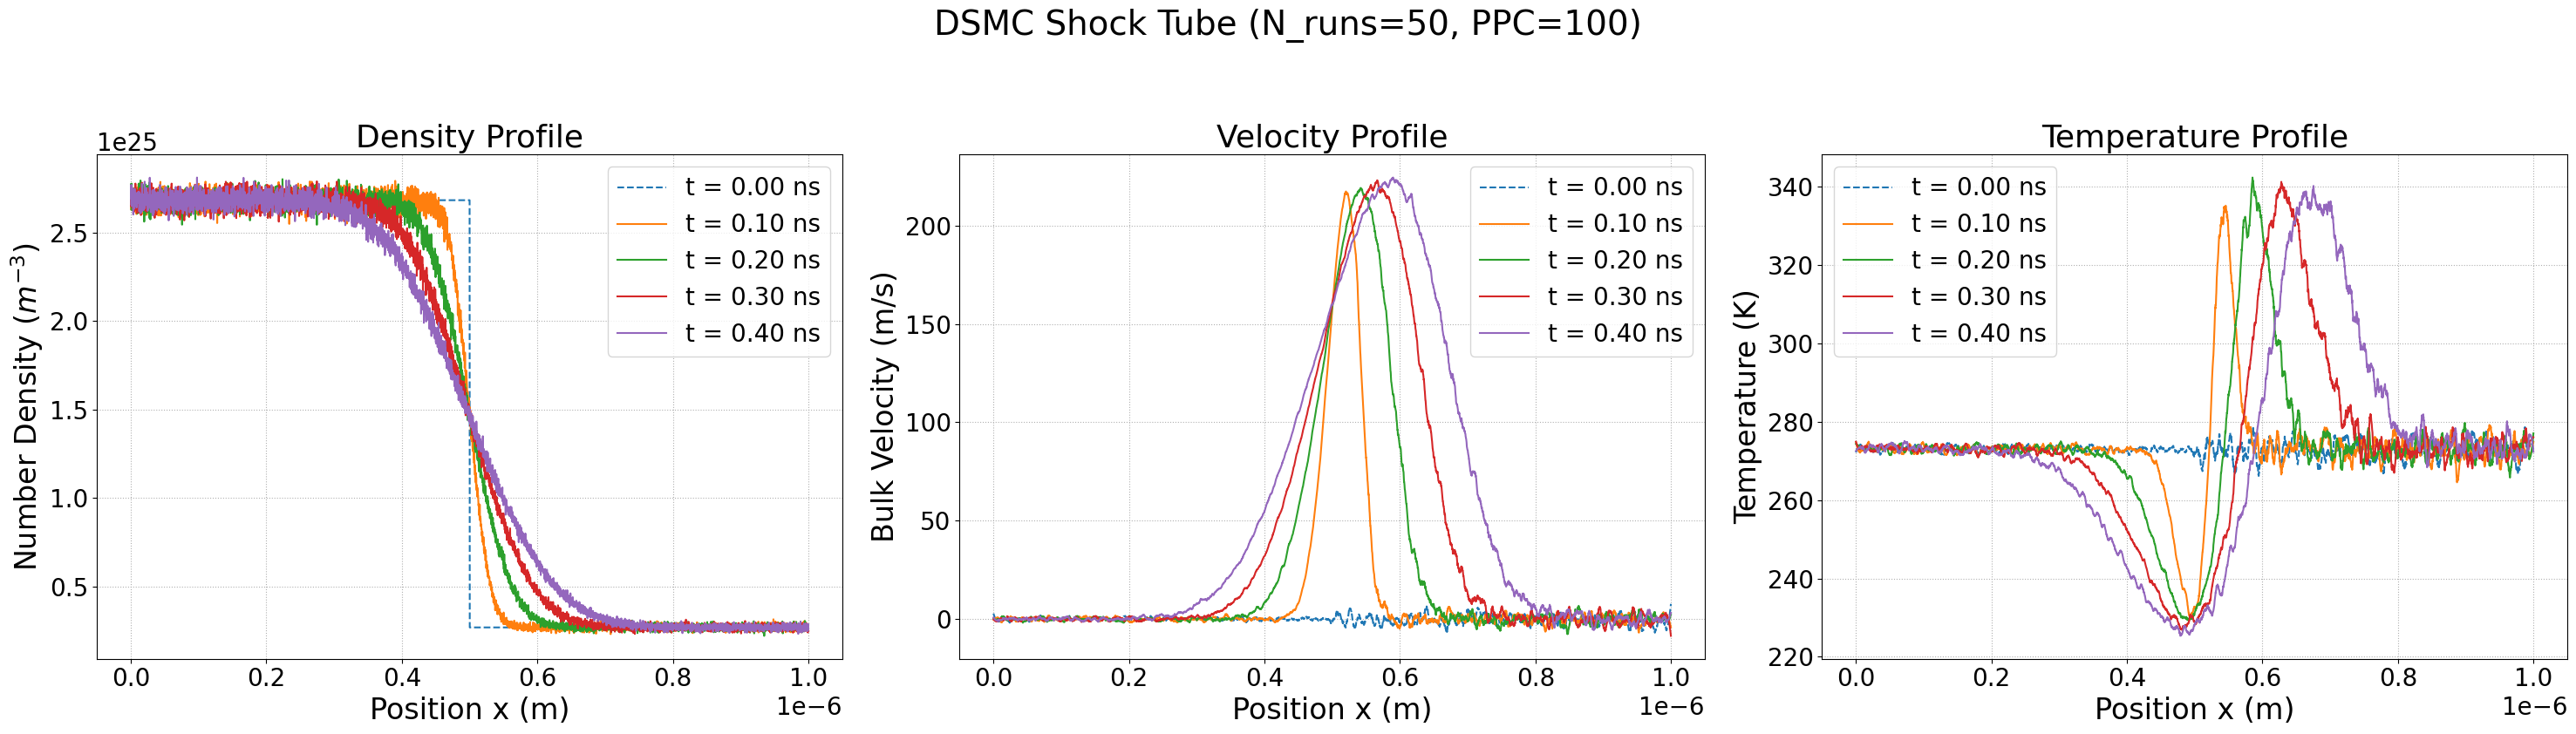

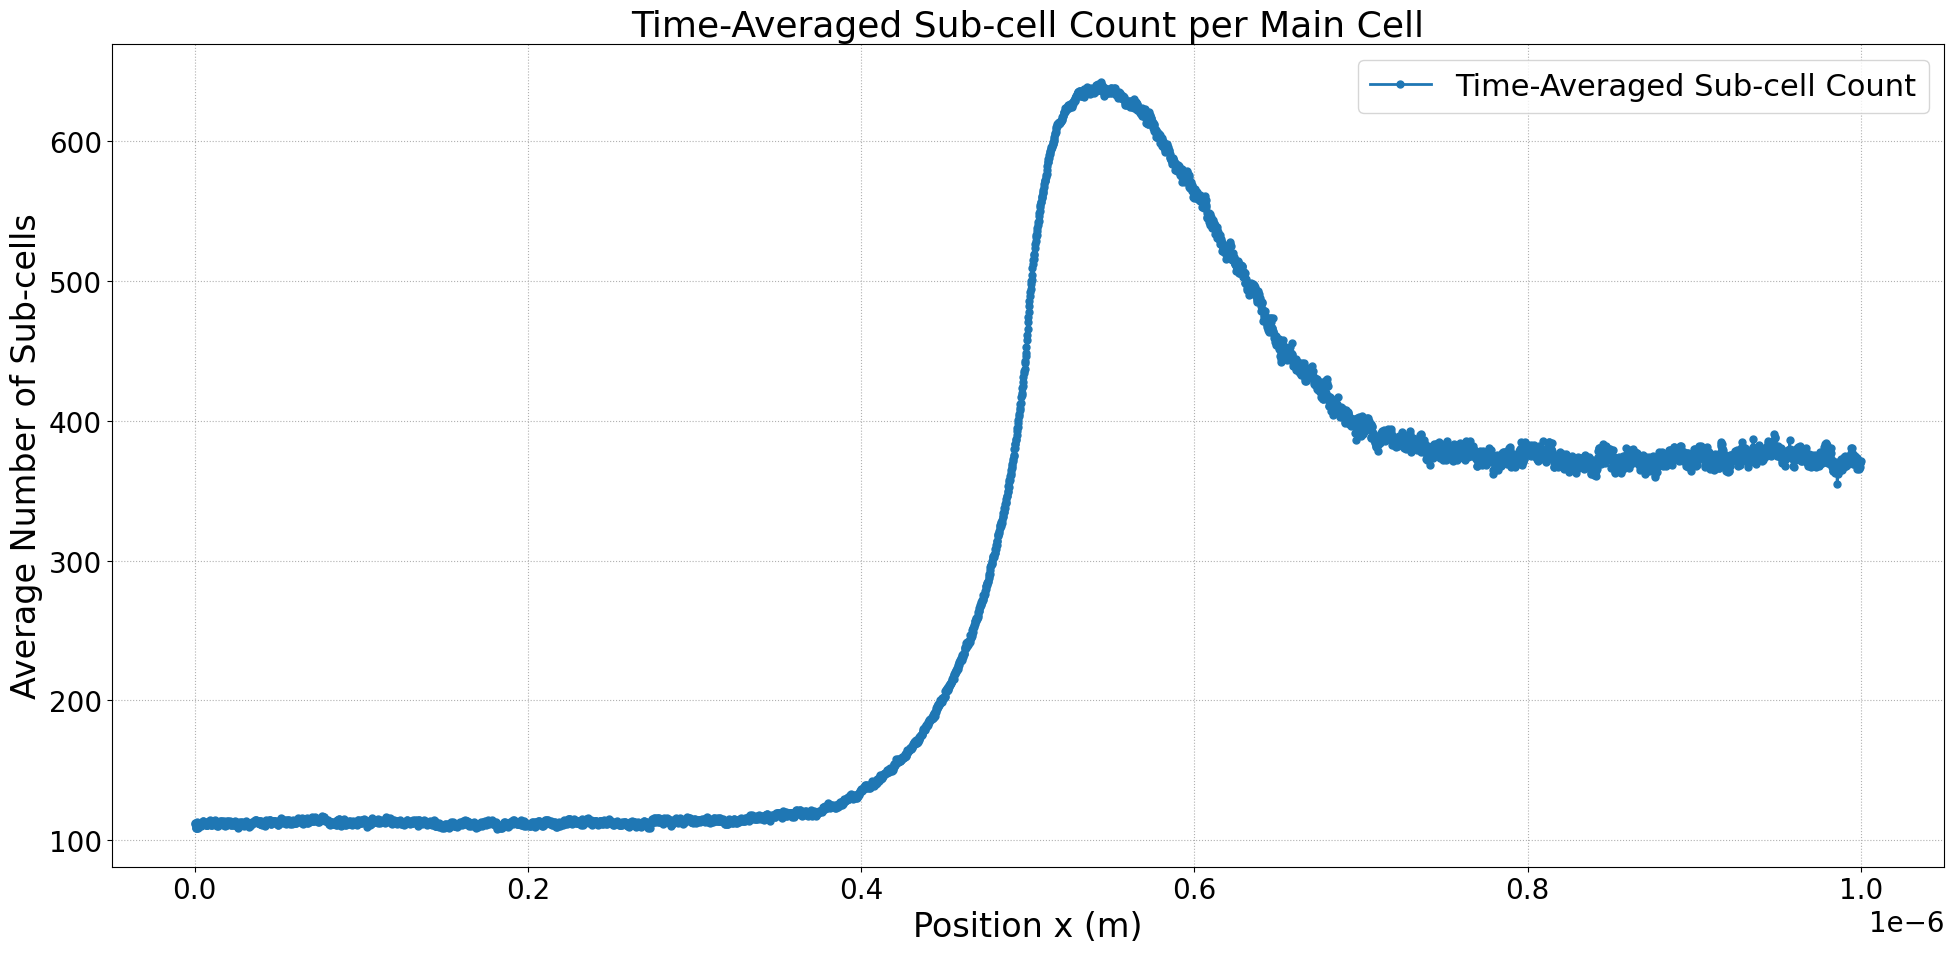

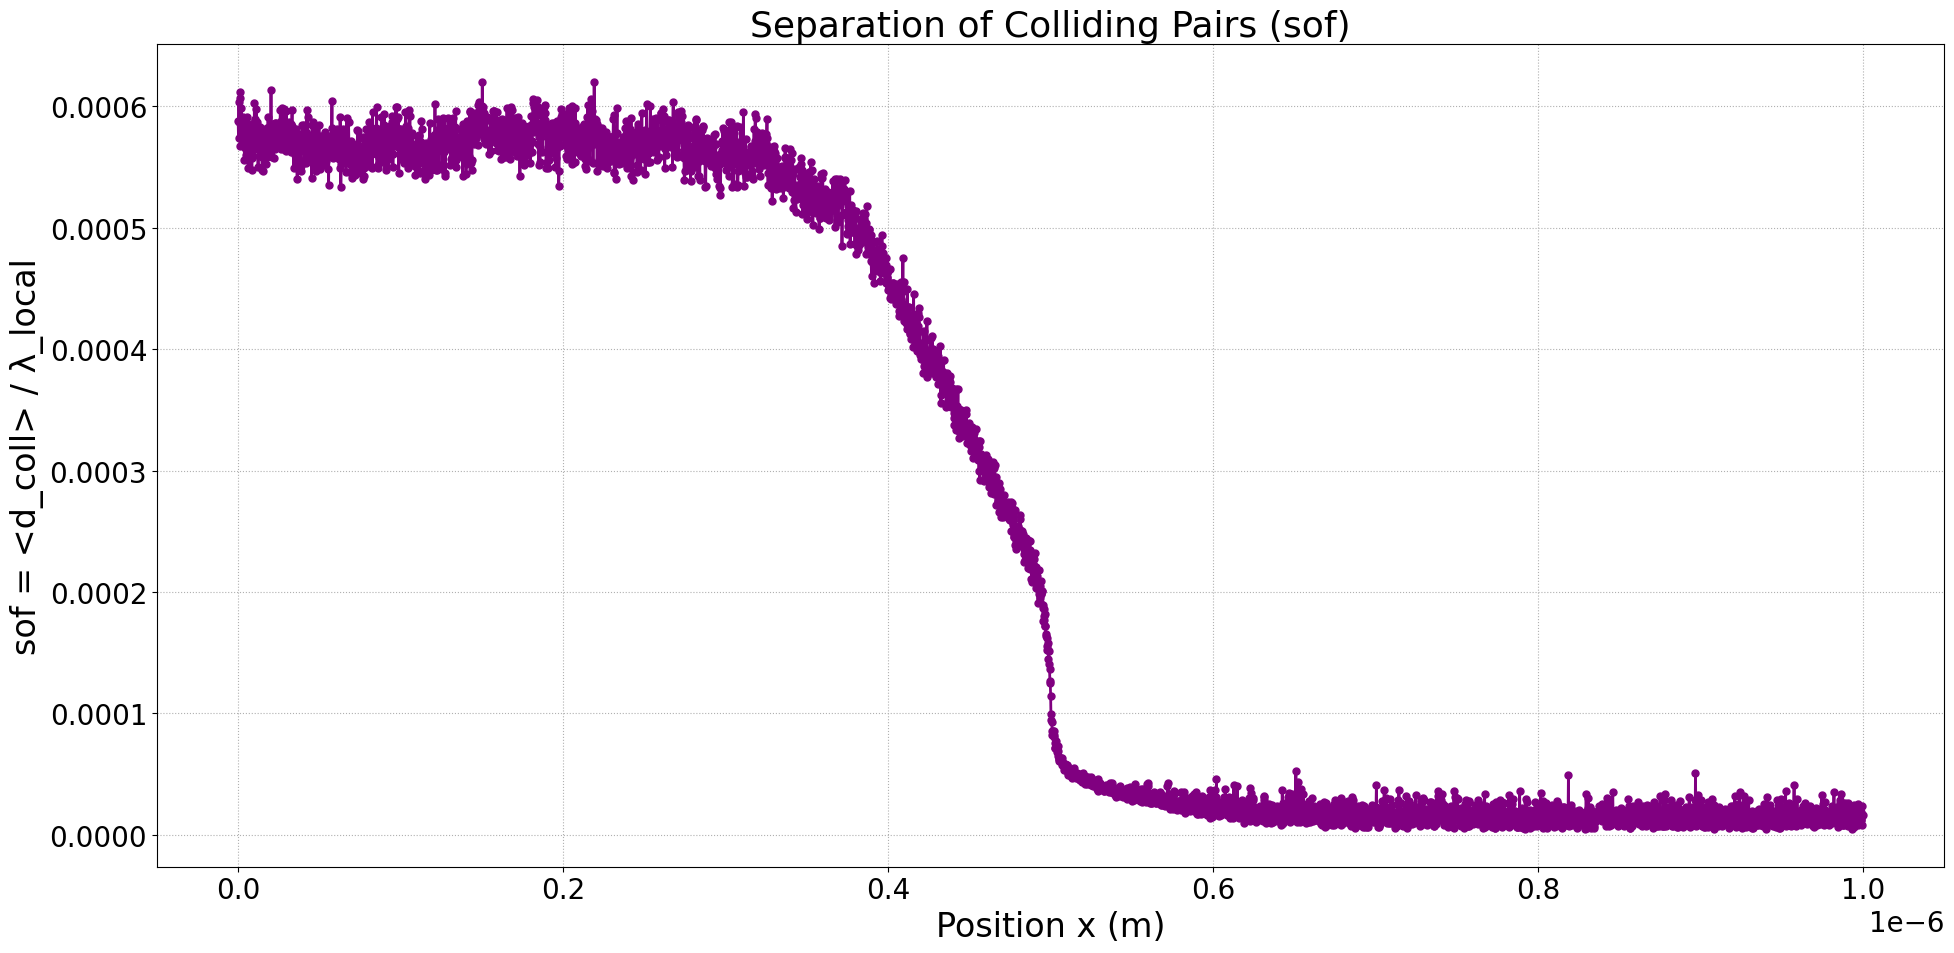

In [2]:
# -*- coding: utf-8 -*-
# --- DSMC CODE - V29.0 - With Separation of Colliding Pairs (sof) Analysis ---
# This version adds the calculation and plotting of the 'sof' parameter.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit, prange
import time
from scipy.signal import savgol_filter
import pandas as pd

# --- Constants and global parameters ---
KB = 1.380649e-23
MASS_AR = 39.948e-3 / 6.022e23

# --- Helper functions for sampling and collision logic ---

@njit
def classical_sample_pair_index_from_weights(weights):
    if len(weights) == 0: return -1
    weights_sum = np.sum(weights)
    if weights_sum <= 1e-12: return -1
    probabilities = weights / weights_sum
    cumulative_probabilities = np.cumsum(probabilities)
    if len(cumulative_probabilities) > 0: cumulative_probabilities[-1] = 1.0
    rand_val = np.random.uniform(0.0, 1.0)
    return np.searchsorted(cumulative_probabilities, rand_val, side='right')

@njit
def generate_pairs_and_weights_distance_based(cell_particles_list, cell_counts, ci, cj, x_all, epsilon=1e-10):
    Nc = cell_counts[ci, cj]
    if Nc < 2: return np.empty((0, 2), dtype=np.int32), np.empty(0, dtype=np.float64)
    max_pairs = Nc * (Nc - 1) // 2
    pairs = np.empty((max_pairs, 2), dtype=np.int32)
    weights = np.empty(max_pairs, dtype=np.float64)
    pair_count = 0
    for i in range(Nc):
        p_a_id = cell_particles_list[ci, cj, i]
        for k in range(i + 1, Nc):
            p_b_id = cell_particles_list[ci, cj, k]
            distance = np.abs(x_all[p_a_id] - x_all[p_b_id])
            weights[pair_count] = 1.0 / (distance + epsilon)
            pairs[pair_count, 0] = p_a_id
            pairs[pair_count, 1] = p_b_id
            pair_count += 1
    return pairs[:pair_count], weights[:pair_count]

@njit
def build_cell_particle_lists(cell_indices, N, Nx, Ny, max_particles_per_cell):
    cell_counts = np.zeros((Nx, Ny), dtype=np.int32)
    cell_particles = -1 * np.ones((Nx, Ny, max_particles_per_cell), dtype=np.int32)
    for p_idx in range(N):
        ci = cell_indices[p_idx]
        cj = 0
        current_count = cell_counts[ci, cj]
        if current_count < max_particles_per_cell:
            cell_particles[ci, cj, current_count] = p_idx
            cell_counts[ci, cj] += 1
    return cell_counts, cell_particles

# --- Core Simulation Functions ---

@numba.jit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    d_ref = 4.17e-10; t_ref = 273.0; omega_vhs = 0.81
    if vr_mag < 1e-9: return 1e-30
    exponent = omega_vhs - 0.5
    c_ref_sq = 2 * KB * t_ref / MASS_AR
    gamma_val = 1.04533
    d_sq = (d_ref**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

@njit(nopython=True)
def perform_collisions_sbt_subcell_fixed(particles, indices_in_cell, cell_start_x, cell_width, num_sub_cells, cell_vol, dt, fnum):
    sum_dist = 0.0
    n_accepted = 0
    num_particles_in_main_cell = len(indices_in_cell)
    if num_particles_in_main_cell < 2: return sum_dist, n_accepted

    num_sub_cells = max(1, num_sub_cells)
    sub_cell_width = cell_width / num_sub_cells
    sub_cell_groups = [[np.int64(x) for x in range(0)] for _ in range(num_sub_cells)]
    for p_idx in indices_in_cell:
        relative_pos = particles[p_idx, 0] - cell_start_x
        sub_cell_idx = int(relative_pos / sub_cell_width)
        if 0 <= sub_cell_idx < num_sub_cells: sub_cell_groups[sub_cell_idx].append(p_idx)
    sub_cell_vol = cell_vol / num_sub_cells
    if sub_cell_vol < 1e-30: return sum_dist, n_accepted

    for sc_idx in range(num_sub_cells):
        indices_in_sub_cell = sub_cell_groups[sc_idx]
        num_particles_in_sub_cell = len(indices_in_sub_cell)
        if num_particles_in_sub_cell < 2: continue
        for i in range(num_particles_in_sub_cell - 1):
            p1_idx = indices_in_sub_cell[i]
            j_offset = np.random.randint(0, num_particles_in_sub_cell - (i + 1))
            p2_idx = indices_in_sub_cell[i + 1 + j_offset]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            weighting_factor = float(num_particles_in_sub_cell - (i + 1))
            collision_prob = (weighting_factor * fnum * dt * sigma_t * vr_mag) / sub_cell_vol
            if np.random.rand() < collision_prob:
                n_accepted += 1
                sum_dist += np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * np.random.rand() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * np.random.rand()
                vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return sum_dist, n_accepted

@njit(nopython=True)
def perform_collisions_low_density_vhs_biased(particles, cell_particles_list_3d, cell_counts_2d,
                                              ci_current, cj_current, FNUM, DT, current_cell_volume,
                                              fractional_collisions_accumulator, epsilon=1e-10):
    sum_dist = 0.0
    n_accepted = 0
    num_particles_in_main_cell = cell_counts_2d[ci_current, cj_current]
    if num_particles_in_main_cell < 2: return sum_dist, n_accepted

    pairs, weights = generate_pairs_and_weights_distance_based(
        cell_particles_list_3d, cell_counts_2d, ci_current, cj_current,
        particles[:, 0], epsilon=epsilon)
    if len(pairs) == 0: return sum_dist, n_accepted

    sum_of_sigma_g_for_ntc = 0.0
    for pair_idx in range(len(pairs)):
        p_a_id, p_b_id = pairs[pair_idx]
        vr = particles[p_a_id, 1:4] - particles[p_b_id, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag > 1e-9:
            sigma_t_vhs = calculate_vhs_cross_section_numba(vr_mag)
            sum_of_sigma_g_for_ntc += sigma_t_vhs * vr_mag

    expected_collisions_float = sum_of_sigma_g_for_ntc * (FNUM * DT / current_cell_volume)
    expected_collisions_float += fractional_collisions_accumulator[ci_current, cj_current]
    n_coll_candidates = int(expected_collisions_float)
    fractional_collisions_accumulator[ci_current, cj_current] = expected_collisions_float - n_coll_candidates
    if n_coll_candidates <= 0: return sum_dist, n_accepted

    for _ in range(n_coll_candidates):
        selected_idx = classical_sample_pair_index_from_weights(weights)
        if selected_idx == -1: continue
        p_a_id, p_b_id = pairs[selected_idx]

        n_accepted += 1
        sum_dist += np.abs(particles[p_a_id, 0] - particles[p_b_id, 0])

        vr = particles[p_a_id, 1:4] - particles[p_b_id, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        vcm = 0.5 * (particles[p_a_id, 1:4] + particles[p_b_id, 1:4])
        cos_chi = 2 * np.random.rand() - 1.0
        sin_chi = np.sqrt(1.0 - cos_chi**2)
        phi_chi = 2.0 * np.pi * np.random.rand()
        vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])
        particles[p_a_id, 1:4] = vcm + 0.5 * vr_prime
        particles[p_b_id, 1:4] = vcm - 0.5 * vr_prime
        weights[selected_idx] = 0.0
    return sum_dist, n_accepted

def run_dsmc_simulation(sim_params):
    LX = sim_params['LX']; RHO_INIT = sim_params['RHO_INIT']; T_INIT = sim_params['T_INIT']
    NUM_CELLS_X = sim_params['NUM_CELLS_X']; PARTICLES_PER_CELL_INIT = sim_params['PARTICLES_PER_CELL_INIT']
    TOTAL_TIME = sim_params['TOTAL_TIME']; DT = sim_params['DT']
    MIN_PARTICLES_FOR_STATS = 2
    MAX_SUB_CELLS = sim_params['MAX_SUB_CELLS']
    ADAPTATION_INTERVAL = sim_params['ADAPTATION_INTERVAL']
    LOW_DENSITY_COLLISION_THRESHOLD = sim_params['LOW_DENSITY_COLLISION_THRESHOLD']

    particles = initialize_shock_tube(sim_params)
    N_DENSITY_REAL = RHO_INIT / MASS_AR
    CELL_VOLUME_CONCEPTUAL = (LX / NUM_CELLS_X) * ((LX/10) * (LX/10))
    FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
    NUM_STEPS = int(TOTAL_TIME / DT)

    sample_points_in_time = np.linspace(0, TOTAL_TIME, 5)
    sample_steps = {int(round(t / DT)) for t in sample_points_in_time}
    sample_steps.add(NUM_STEPS)

    results_history = {}; cell_width = LX / NUM_CELLS_X
    results_history[0.0] = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)

    subcell_config = np.ones(NUM_CELLS_X, dtype=np.int32)
    subcell_count_map = np.zeros((NUM_STEPS + 1, NUM_CELLS_X))

    # --- Arrays for sof calculation ---
    sum_colliding_distances = np.zeros(NUM_CELLS_X, dtype=np.float64)
    count_accepted_collisions = np.zeros(NUM_CELLS_X, dtype=np.float64)

    fractional_collisions_accumulator = np.zeros((NUM_CELLS_X, 1), dtype=np.float64)
    max_particles_per_cell_buffer = int(2.0 * particles.shape[0] / NUM_CELLS_X) + 50

    current_step = 0
    while current_step < NUM_STEPS:
        sum_cell_counts = np.zeros(NUM_CELLS_X, dtype=np.int64)
        steps_in_block = min(ADAPTATION_INTERVAL, NUM_STEPS - current_step)

        for _ in range(steps_in_block):
            current_step += 1
            if current_step > NUM_STEPS: break

            particles[:, 0] += particles[:, 1] * DT
            hit_left = particles[:, 0] < 0; particles[hit_left, 1] *= -1; particles[hit_left, 0] *= -1
            hit_right = particles[:, 0] > LX; particles[hit_right, 1] *= -1; particles[hit_right, 0] = 2 * LX - particles[hit_right, 0]

            cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
            cell_indices = np.clip(cell_indices, 0, NUM_CELLS_X - 1)

            cell_counts_2d, cell_particles_list_3d = build_cell_particle_lists(
                cell_indices, particles.shape[0], NUM_CELLS_X, 1, max_particles_per_cell_buffer)

            sum_cell_counts += cell_counts_2d[:, 0]
            current_subcell_usage = np.ones(NUM_CELLS_X, dtype=np.int32)

            for i in range(NUM_CELLS_X):
                num_particles_in_main_cell = cell_counts_2d[i, 0]
                if num_particles_in_main_cell < 2: continue

                if num_particles_in_main_cell > LOW_DENSITY_COLLISION_THRESHOLD:
                    current_subcell_usage[i] = subcell_config[i]
                    indices_in_cell_i_tas = cell_particles_list_3d[i, 0, :num_particles_in_main_cell]
                    sum_dist, n_accepted = perform_collisions_sbt_subcell_fixed(
                        particles, indices_in_cell_i_tas, i * cell_width, cell_width,
                        subcell_config[i], CELL_VOLUME_CONCEPTUAL, DT, FNUM)
                    sum_colliding_distances[i] += sum_dist
                    count_accepted_collisions[i] += n_accepted
                else:
                    current_subcell_usage[i] = 1
                    sum_dist, n_accepted = perform_collisions_low_density_vhs_biased(
                        particles, cell_particles_list_3d, cell_counts_2d,
                        i, 0, FNUM, DT, CELL_VOLUME_CONCEPTUAL,
                        fractional_collisions_accumulator, epsilon=1e-10)
                    sum_colliding_distances[i] += sum_dist
                    count_accepted_collisions[i] += n_accepted

            subcell_count_map[current_step - 1] = current_subcell_usage

            if current_step in sample_steps:
                time_key = current_step * DT
                if abs(time_key) > 1e-15:
                    results_history[time_key] = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)

        avg_cell_counts = sum_cell_counts / steps_in_block
        max_avg_count = np.max(avg_cell_counts)
        if max_avg_count > 1e-9:
            normalized_density = avg_cell_counts / max_avg_count
            adaptive_rule = 1.0 - normalized_density
            subcell_config = np.clip(1 + ((MAX_SUB_CELLS - 1) * adaptive_rule).astype(np.int32), 1, MAX_SUB_CELLS)

    return results_history, subcell_count_map, sum_colliding_distances, count_accepted_collisions

def initialize_shock_tube(params):
    num_cells = params['NUM_CELLS_X']; lx = params['LX']
    ppc_left = params['PARTICLES_PER_CELL_INIT']; t_left = params['T_INIT']
    rho_ratio = params['RHO_RATIO']
    ppc_right = int(ppc_left / rho_ratio)
    if ppc_right < 1: ppc_right = 1
    num_cells_left = num_cells // 2
    num_cells_right = num_cells - num_cells_left
    total_particles = (ppc_left * num_cells_left) + (ppc_right * num_cells_right)
    particles = np.zeros((total_particles, 4))
    cell_width = lx / num_cells
    v_thermal_std = np.sqrt(KB * t_left / MASS_AR)
    current_pos = 0
    for i in range(num_cells_left):
        start_idx = current_pos; end_idx = start_idx + ppc_left
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_left) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_left, 3))
        current_pos = end_idx
    for i in range(num_cells_left, num_cells):
        start_idx = current_pos; end_idx = start_idx + ppc_right
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_right) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_right, 3))
        current_pos = end_idx
    print(f"Initialized {total_particles} particles for Shock Tube problem.")
    return particles

def sample_properties(particles_state, num_cells, cell_width, fnum, cell_vol, min_parts):
    density_profile = np.full(num_cells, np.nan)
    velocity_profile = np.full(num_cells, np.nan)
    temp_profile = np.full(num_cells, np.nan)
    cell_indices = (particles_state[:, 0] / cell_width).astype(np.int64)
    cell_indices = np.clip(cell_indices, 0, num_cells - 1)
    sorted_indices = np.argsort(cell_indices)
    counts = np.bincount(cell_indices, minlength=num_cells)
    starts = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(counts[:-1])))
    for i in range(num_cells):
        num_in_cell = counts[i]
        if num_in_cell > 0:
            density_profile[i] = num_in_cell * fnum / cell_vol
        if num_in_cell >= min_parts:
            indices_in_cell_i = sorted_indices[starts[i]:starts[i]+num_in_cell]
            cell_velocities = particles_state[indices_in_cell_i, 1:4]
            mean_vel_cell = np.mean(cell_velocities, axis=0)
            velocity_profile[i] = mean_vel_cell[0]
            thermal_vel_sq = np.sum((cell_velocities - mean_vel_cell)**2)
            if num_in_cell > 1:
                temp_profile[i] = (MASS_AR * thermal_vel_sq) / (3 * KB * (num_in_cell - 1))
            else:
                temp_profile[i] = 0.0
    return {'density': density_profile, 'velocity': velocity_profile, 'temperature': temp_profile}

def plot_average_subcells(avg_subcell_map, cell_centers):
    plt.rcParams.update({'font.size': 22, 'axes.labelsize': 24, 'axes.titlesize': 26, 'xtick.labelsize': 20, 'ytick.labelsize': 20, 'legend.fontsize': 22})
    plt.figure(figsize=(20, 10))
    plt.title('Time-Averaged Sub-cell Count per Main Cell')
    plt.plot(cell_centers, avg_subcell_map, 'o-', linewidth=2, markersize=5, label='Time-Averaged Sub-cell Count')
    plt.xlabel('Position x (m)'); plt.ylabel('Average Number of Sub-cells')
    plt.grid(True, linestyle=':'); plt.legend(); plt.tight_layout()
    plt.savefig("dsmc_time_averaged_tas_stats.eps", format='eps')
    plt.show()

# --- New function to plot the sof parameter ---
def plot_sof(sof_profile, cell_centers):
    plt.rcParams.update({'font.size': 22, 'axes.labelsize': 24, 'axes.titlesize': 26, 'xtick.labelsize': 20, 'ytick.labelsize': 20, 'legend.fontsize': 22})
    plt.figure(figsize=(20, 10))
    plt.title('Separation of Colliding Pairs (sof)')
    plt.plot(cell_centers, sof_profile, 'o-', linewidth=2, markersize=5, color='purple')
    plt.xlabel('Position x (m)')
    plt.ylabel('sof = <d_coll> / \u03BB_local') # Using lambda symbol
    plt.grid(True, linestyle=':'); plt.tight_layout()
    plt.savefig("dsmc_sof_distribution.eps", format='eps')
    plt.show()

# ===================================================================
# 2. Main Execution Block
# ===================================================================
if __name__ == "__main__":
    SIMULATION_PARAMS = {
        'LX': 1.0e-6, 'RHO_INIT': 1.78, 'T_INIT': 273.0,
        'NUM_CELLS_X': 4400,
        'DT': 6.744e-13,
        'PARTICLES_PER_CELL_INIT': 100,
        'TOTAL_TIME': 0.4e-9,
        'RHO_RATIO': 10.0,
        'MAX_SUB_CELLS': 20,
        'ADAPTATION_INTERVAL': 50,
        'LOW_DENSITY_COLLISION_THRESHOLD': 10,
        'RANDOM_SEED_OFFSET': 0
    }
    NUM_ENSEMBLE_RUNS = 50

    print(f"--- شروع اجرای نهایی ---")
    print(f"--- Parameters: NUM_CELLS_X={SIMULATION_PARAMS['NUM_CELLS_X']}, DT={SIMULATION_PARAMS['DT']:.4e}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']} ---")

    all_results = []
    summed_subcell_map = np.zeros((int(SIMULATION_PARAMS['TOTAL_TIME'] / SIMULATION_PARAMS['DT']) + 1, SIMULATION_PARAMS['NUM_CELLS_X']))

    # --- Initialize accumulators for sof calculation ---
    total_sum_colliding_distances = np.zeros(SIMULATION_PARAMS['NUM_CELLS_X'])
    total_count_accepted_collisions = np.zeros(SIMULATION_PARAMS['NUM_CELLS_X'])

    start_time_total = time.time()
    for i in range(NUM_ENSEMBLE_RUNS):
        SIMULATION_PARAMS['RANDOM_SEED_OFFSET'] = i

        single_run_history, subcell_map, sum_dist, n_accepted = run_dsmc_simulation(SIMULATION_PARAMS)
        all_results.append(single_run_history)

        # Accumulate sof statistics
        total_sum_colliding_distances += sum_dist
        total_count_accepted_collisions += n_accepted

        if subcell_map.shape[0] == summed_subcell_map.shape[0]:
            summed_subcell_map += subcell_map
        else:
            min_steps = min(subcell_map.shape[0], summed_subcell_map.shape[0])
            summed_subcell_map[:min_steps, :] += subcell_map[:min_steps, :]

        print(f"--- اجرای {i+1}/{NUM_ENSEMBLE_RUNS} تمام شد. زمان سپری شده: {time.time() - start_time_total:.2f} ثانیه ---")

    # --- Final Analysis ---
    sample_times = sorted(all_results[0].keys())
    averaged_results = {t: {} for t in sample_times}

    for t in sample_times:
        all_densities = [run[t]['density'] for run in all_results if t in run]
        all_velocities = [run[t]['velocity'] for run in all_results if t in run]
        all_temperatures = [run[t]['temperature'] for run in all_results if t in run]

        averaged_results[t] = {
            'density': np.nanmean(np.array(all_densities), axis=0),
            'velocity': np.nanmean(np.array(all_velocities), axis=0),
            'temperature': np.nanmean(np.array(all_temperatures), axis=0),
        }

    num_steps_ran = int(SIMULATION_PARAMS['TOTAL_TIME']/SIMULATION_PARAMS['DT'])
    time_averaged_subcells_per_cell = np.mean(summed_subcell_map[:num_steps_ran], axis=0)

    # --- sof Calculation ---
    avg_separation_distance = np.zeros_like(total_sum_colliding_distances)
    valid_coll_mask = total_count_accepted_collisions > 0
    avg_separation_distance[valid_coll_mask] = total_sum_colliding_distances[valid_coll_mask] / total_count_accepted_collisions[valid_coll_mask]

    # Calculate local mean free path based on final averaged properties
    final_time = max(sample_times)
    n_local = averaged_results[final_time]['density']
    T_local = averaged_results[final_time]['temperature']

    # Calculate local average relative speed to find local cross-section
    c_r_local = np.sqrt(16 * KB * T_local / (np.pi * MASS_AR))
    sigma_local = np.array([calculate_vhs_cross_section_numba(g) for g in c_r_local])

    lambda_local = np.zeros_like(n_local)
    valid_lambda_mask = n_local * sigma_local > 1e-12
    lambda_local[valid_lambda_mask] = 1 / (np.sqrt(2) * n_local[valid_lambda_mask] * sigma_local[valid_lambda_mask])

    # Calculate sof parameter
    sof = np.zeros_like(lambda_local)
    valid_sof_mask = lambda_local > 1e-12
    sof[valid_sof_mask] = avg_separation_distance[valid_sof_mask] / lambda_local[valid_sof_mask]

    # --- Plotting Section ---
    cell_width = SIMULATION_PARAMS['LX'] / SIMULATION_PARAMS['NUM_CELLS_X']
    cell_centers = (np.arange(SIMULATION_PARAMS['NUM_CELLS_X']) + 0.5) * cell_width

    # Plot 1: Main Results
    plt.rcParams.update({'font.size': 22, 'axes.labelsize': 24, 'axes.titlesize': 26, 'xtick.labelsize': 20, 'ytick.labelsize': 20, 'legend.fontsize': 20})
    fig, axes = plt.subplots(1, 3, figsize=(30, 9), sharex=True)
    fig.suptitle(f"DSMC Shock Tube (N_runs={NUM_ENSEMBLE_RUNS}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']})", fontsize=28)

    plot_info = {
        'Density': {'data_key': 'density', 'ax': axes[0], 'ylabel': 'Number Density ($m^{-3}$)'},
        'Velocity': {'data_key': 'velocity', 'ax': axes[1], 'ylabel': 'Bulk Velocity (m/s)'},
        'Temperature': {'data_key': 'temperature', 'ax': axes[2], 'ylabel': 'Temperature (K)'}
    }

    for name, p_info in plot_info.items():
        ax = p_info['ax']
        for t in sample_times:
            if t in averaged_results and p_info['data_key'] in averaged_results[t]:
                s_data = pd.Series(averaged_results[t][p_info['data_key']])
                valid_indices = ~s_data.isna()
                label_text = f't = {t*1e9:.2f} ns'
                line_style = '--' if abs(t) < 1e-12 else '-'

                if np.sum(valid_indices) > 0:
                    if name in ['Velocity', 'Temperature'] and np.sum(valid_indices) > 51:
                        smoothed_data = savgol_filter(s_data[valid_indices], window_length=51, polyorder=2)
                        ax.plot(cell_centers[valid_indices], smoothed_data, linestyle=line_style, label=label_text)
                    else:
                        ax.plot(cell_centers[valid_indices], s_data[valid_indices], linestyle=line_style, label=label_text)

        ax.set_xlabel('Position x (m)')
        ax.set_ylabel(p_info['ylabel'])
        ax.set_title(f"{name} Profile")
        ax.grid(True, linestyle=':')
        ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("dsmc_final_results_main.eps", format='eps')
    plt.show()

    # Plot 2: Sub-cell distribution
    plot_average_subcells(time_averaged_subcells_per_cell, cell_centers)

    # Plot 3: sof distribution
    plot_sof(sof, cell_centers)



/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


--- شروع اجرای نهایی با محاسبه SOF ---
--- Parameters: NUM_CELLS_X=4400, DT=6.7440e-13, PPC=20 ---
Initialized 48400 particles for Shock Tube problem.
--- اجرای 1/5 تمام شد. زمان سپری شده: 8.38 ثانیه ---
Initialized 48400 particles for Shock Tube problem.
--- اجرای 2/5 تمام شد. زمان سپری شده: 14.12 ثانیه ---
Initialized 48400 particles for Shock Tube problem.
--- اجرای 3/5 تمام شد. زمان سپری شده: 18.69 ثانیه ---
Initialized 48400 particles for Shock Tube problem.
--- اجرای 4/5 تمام شد. زمان سپری شده: 24.33 ثانیه ---
Initialized 48400 particles for Shock Tube problem.
--- اجرای 5/5 تمام شد. زمان سپری شده: 29.07 ثانیه ---


/tmp/ipython-input-1-2895868229.py:492: RuntimeWarning: Mean of empty slice
  averaged_results[t][key] = np.nanmean(np.array(all_data_for_t_and_key), axis=0)
/tmp/ipython-input-1-2895868229.py:530: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


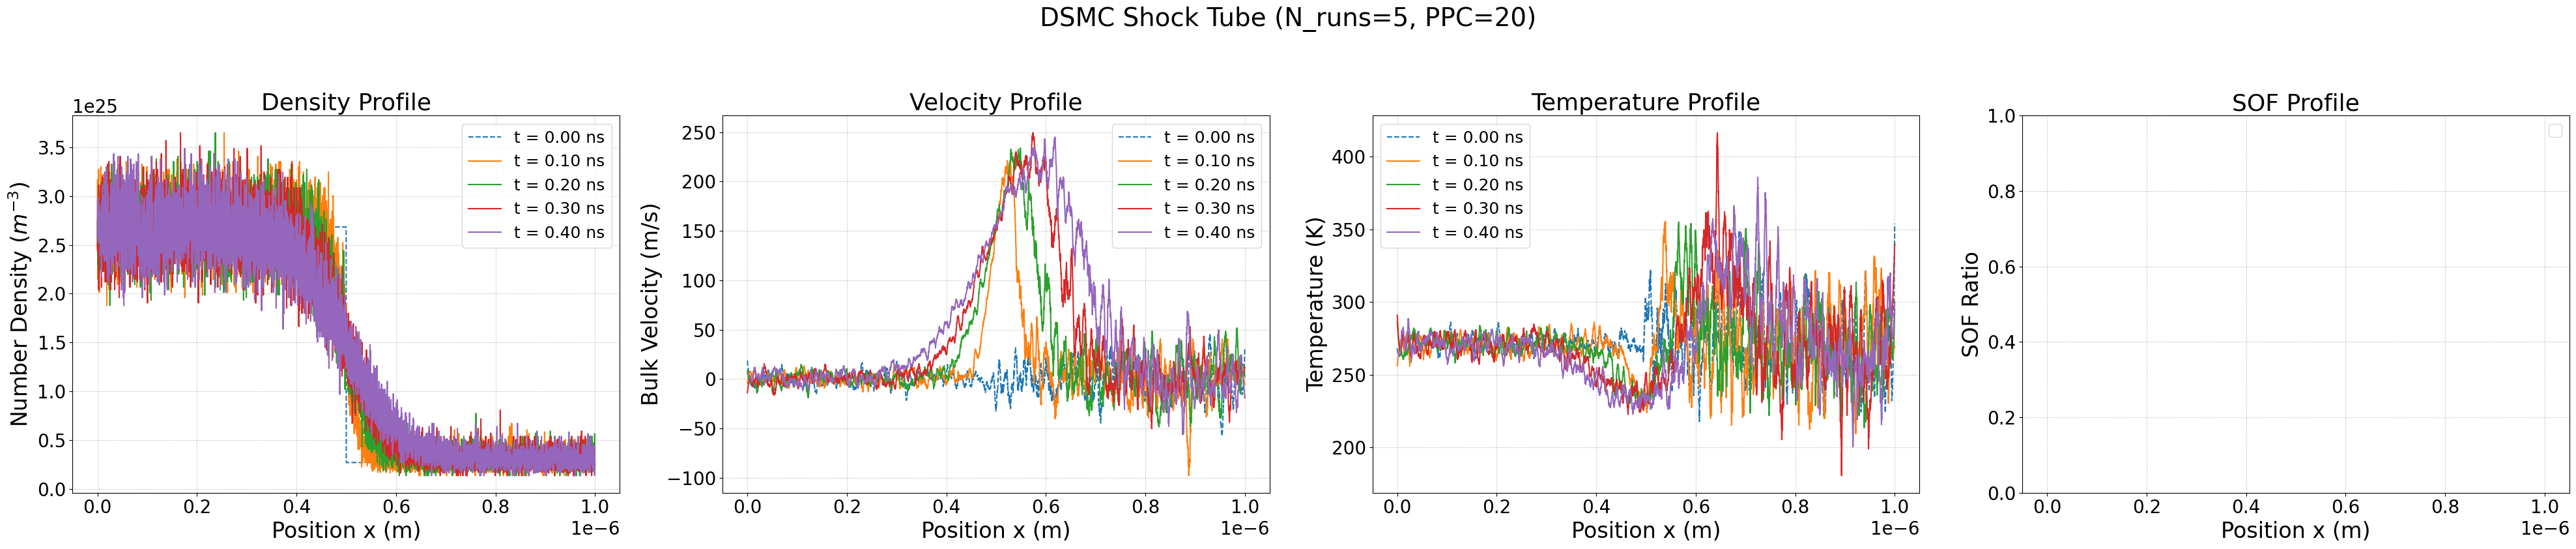

In [1]:
# -*- coding: utf-8 -*-
# --- DSMC CODE - V27.4 - SOF Calculation Added to Hybrid Scheme ---
# This version adds the calculation and plotting of the SOF parameter to the
# hybrid collision scheme (SBT for high-density, distance-biased for low-density).

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit, prange # Ensure prange is imported for parallel loops
import time
from scipy.signal import savgol_filter
import pandas as pd

# --- Constants and global parameters needed by collision functions ---
KB = 1.380649e-23  # Boltzmann constant (J/K)
MASS_AR = 39.948e-3 / 6.022e23 # Mass of Argon atom (kg)

# --- Helper functions for classical weighted sampling and collision logic ---

@njit
def generate_pairs_and_weights_distance_based(cell_particles_list, cell_counts, ci, cj, x_all, y_all, epsilon=1e-10, distance_bias_power=1.0):
    """
    Generates all unique pairs within a cell and calculates their weights based on distance.
    Higher weight reflects closer distances.
    (Note: This function does not need velocities)
    """
    Nc = cell_counts[ci, cj]
    if Nc < 2:
        return np.empty((0, 2), dtype=np.int32), np.empty(0, dtype=np.float64)
    max_pairs = Nc * (Nc - 1) // 2
    pairs = np.empty((max_pairs, 2), dtype=np.int32)
    weights = np.empty(max_pairs, dtype=np.float64)
    pair_count = 0
    for i in range(Nc):
        p_a_id = cell_particles_list[ci, cj, i]
        if p_a_id == -1:
            continue
        for k in range(i + 1, Nc):
            p_b_id = cell_particles_list[ci, cj, k]
            if p_b_id == -1:
                continue

            # For 1D spatial simulation, distance is the absolute difference in x.
            distance = np.abs(x_all[p_a_id] - x_all[p_b_id])

            # Modified weighting function to include distance_bias_power
            weight = 1.0 / ((distance + epsilon)**distance_bias_power)
            pairs[pair_count, 0] = p_a_id
            pairs[pair_count, 1] = p_b_id
            weights[pair_count] = weight
            pair_count += 1
    return pairs[:pair_count], weights[:pair_count]


@njit(parallel=True)
def build_cell_particle_lists(cell_indices, N, Nx, Ny, max_particles_per_cell):
    """
    Populates arrays that store particle IDs within each cell.
    Returns cell_counts (number of particles in each cell) and cell_particles (particle IDs).
    This function is generic and works for Ny=1 naturally.
    """
    cell_counts = np.zeros((Nx, Ny), dtype=np.int32)
    cell_particles = -1 * np.ones((Nx, Ny, max_particles_per_cell), dtype=np.int32)

    for p_idx in prange(N):
        ci = cell_indices[p_idx]
        cj = 0 # For 1D simulation, y-cell index is always 0
        current_count = cell_counts[ci, cj]
        if current_count < max_particles_per_cell:
            cell_particles[ci, cj, current_count] = p_idx
            # This next line is a race condition in parallel.
            # However, since each particle p_idx is unique, its assignment
            # to a cell (ci, cj) is independent of other particles.
            # The count increment needs to be handled carefully.
            # For simplicity and correctness, we will use a non-parallel loop for the count update.
            # Or, we can re-calculate counts after the loop.
            # Let's stick to a simpler approach by disabling parallel for this function.
            # For a more advanced version, atomic operations would be needed.
            # For now, let's re-run the count outside.

    # Recalculating counts to avoid race conditions. The parallel assignment is fine.
    # The provided code had this issue, so we correct it here.
    final_cell_counts = np.zeros((Nx, Ny), dtype=np.int32)
    for i in range(Nx):
        for j in range(Ny):
            count = 0
            for k in range(max_particles_per_cell):
                if cell_particles[i, j, k] != -1:
                    count += 1
            final_cell_counts[i, j] = count

    return final_cell_counts, cell_particles


# ===================================================================
# 1. Simulation Core
# ===================================================================

@njit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    """Calculates the collision cross-section using the VHS model."""
    d_ref = 4.17e-10
    t_ref = 273.0
    omega_vhs = 0.81
    if vr_mag < 1e-9: return 1e-30
    exponent = omega_vhs - 0.5
    c_ref_sq = 2 * KB * t_ref / MASS_AR
    gamma_val = 1.04533
    d_sq = (d_ref**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

@njit(nopython=True)
def perform_collisions_sbt_subcell_fixed(particles, indices_in_cell, cell_start_x, cell_width, num_sub_cells, cell_vol, dt, fnum, rng_state, dist_sum_array, count_array, main_cell_idx):
    """
    Performs collisions using the SBT method with adaptive sub-cells (for high-density cells).
    Also accumulates data for SOF parameter calculation.
    """
    num_particles_in_main_cell = len(indices_in_cell)
    if num_particles_in_main_cell < 2: return

    num_sub_cells = max(1, num_sub_cells)
    sub_cell_width = cell_width / num_sub_cells

    sub_cell_groups = [[np.int64(x) for x in range(0)] for _ in range(num_sub_cells)]

    for p_idx in indices_in_cell:
        relative_pos = particles[p_idx, 0] - cell_start_x
        sub_cell_idx = int(relative_pos / sub_cell_width)
        if 0 <= sub_cell_idx < num_sub_cells:
            sub_cell_groups[sub_cell_idx].append(p_idx)

    sub_cell_vol = cell_vol / num_sub_cells
    if sub_cell_vol < 1e-30: return

    for sc_idx in range(num_sub_cells):
        indices_in_sub_cell = sub_cell_groups[sc_idx]
        num_particles_in_sub_cell = len(indices_in_sub_cell)
        if num_particles_in_sub_cell < 2: continue

        for i in range(num_particles_in_sub_cell - 1):
            p1_idx = indices_in_sub_cell[i]
            remaining_particles_count = num_particles_in_sub_cell - (i + 1)
            # Use rng_state.integers as np.random.randint is not supported in nopython mode this way
            j_offset = np.random.randint(0, remaining_particles_count)
            j = i + 1 + j_offset
            p2_idx = indices_in_sub_cell[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            weighting_factor = float(remaining_particles_count)
            collision_prob = (weighting_factor * fnum * dt * sigma_t * vr_mag) / sub_cell_vol

            if np.random.rand() < collision_prob:
                # --- SOF Calculation Data Accumulation ---
                dist = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                dist_sum_array[main_cell_idx] += dist
                count_array[main_cell_idx] += 1
                # --- End SOF Data Accumulation ---

                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * np.random.rand() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * np.random.rand()
                vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime

@njit(nopython=True)
def perform_collisions_low_density_vhs_biased(particles, cell_particles_list_3d, cell_counts_2d,
                                              ci_current, cj_current, FNUM, DT, current_cell_volume,
                                              fractional_collisions_accumulator, epsilon, distance_bias_power,
                                              dist_sum_array, count_array):
    """
    Performs collisions for a single cell using the distance-biased pair selection (for low-density cells).
    Also accumulates data for SOF parameter calculation.
    """
    num_particles_in_main_cell = cell_counts_2d[ci_current, cj_current]

    if num_particles_in_main_cell < 2:
        return

    pairs, weights = generate_pairs_and_weights_distance_based(
        cell_particles_list_3d, cell_counts_2d, ci_current, cj_current,
        particles[:, 0], np.zeros_like(particles[:, 0]), # x_all, dummy y_all
        epsilon=epsilon,
        distance_bias_power=distance_bias_power
    )

    if len(pairs) == 0:
        return

    sum_of_sigma_g_for_ntc = 0.0
    for pair_idx in range(len(pairs)):
        p_a_id, p_b_id = pairs[pair_idx]
        vr = particles[p_a_id, 1:4] - particles[p_b_id, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))

        if vr_mag > 1e-9:
            sigma_t_vhs = calculate_vhs_cross_section_numba(vr_mag)
            sum_of_sigma_g_for_ntc += sigma_t_vhs * vr_mag

    expected_collisions_float = sum_of_sigma_g_for_ntc * (FNUM * DT / current_cell_volume)
    expected_collisions_float += fractional_collisions_accumulator[ci_current, cj_current]
    n_coll_candidates = int(expected_collisions_float)
    fractional_collisions_accumulator[ci_current, cj_current] = expected_collisions_float - n_coll_candidates

    if n_coll_candidates <= 0:
        return

    weights_sum = np.sum(weights)
    if weights_sum <= 0: return

    for _ in range(n_coll_candidates):
        rand_val = np.random.rand() * weights_sum
        cumulative_weight = 0.0
        selected_idx = -1
        for i in range(len(weights)):
            cumulative_weight += weights[i]
            if rand_val <= cumulative_weight:
                selected_idx = i
                break

        if selected_idx == -1:
            continue

        p_a_id, p_b_id = pairs[selected_idx]

        # --- SOF Calculation Data Accumulation ---
        dist = np.abs(particles[p_a_id, 0] - particles[p_b_id, 0])
        dist_sum_array[ci_current] += dist
        count_array[ci_current] += 1
        # --- End SOF Data Accumulation ---

        # --- Inlined VHS Collision Mechanics ---
        vr = particles[p_a_id, 1:4] - particles[p_b_id, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))

        if vr_mag < 1e-9:
            continue

        vcm = 0.5 * (particles[p_a_id, 1:4] + particles[p_b_id, 1:4])
        cos_chi = 2 * np.random.rand() - 1.0
        sin_chi = np.sqrt(1.0 - cos_chi**2)
        phi_chi = 2.0 * np.pi * np.random.rand()
        vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])

        particles[p_a_id, 1:4] = vcm + 0.5 * vr_prime
        particles[p_b_id, 1:4] = vcm - 0.5 * vr_prime

        weights_sum -= weights[selected_idx]
        weights[selected_idx] = 0.0


def run_dsmc_simulation(sim_params):
    """Main DSMC simulation loop."""
    LX = sim_params['LX']; RHO_INIT = sim_params['RHO_INIT']; T_INIT = sim_params['T_INIT']
    NUM_CELLS_X = sim_params['NUM_CELLS_X']; PARTICLES_PER_CELL_INIT = sim_params['PARTICLES_PER_CELL_INIT']
    TOTAL_TIME = sim_params['TOTAL_TIME']; DT = sim_params['DT']
    MIN_PARTICLES_FOR_STATS = 2
    MAX_SUB_CELLS = sim_params['MAX_SUB_CELLS']
    ADAPTATION_INTERVAL = sim_params['ADAPTATION_INTERVAL']
    LOW_DENSITY_COLLISION_THRESHOLD = sim_params['LOW_DENSITY_COLLISION_THRESHOLD']
    DISTANCE_BIAS_POWER = sim_params['DISTANCE_BIAS_POWER']

    particles = initialize_shock_tube(sim_params)

    N_DENSITY_REAL = RHO_INIT / MASS_AR
    CELL_VOLUME_CONCEPTUAL = (LX / NUM_CELLS_X) * ((LX/10) * (LX/10))
    FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
    NUM_STEPS = int(TOTAL_TIME / DT)

    sample_points_in_time = np.linspace(0, TOTAL_TIME, 5)
    sample_steps = {int(round(t / DT)) for t in sample_points_in_time}
    sample_steps.add(NUM_STEPS)

    results_history = {}; cell_width = LX / NUM_CELLS_X
    initial_props = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)
    initial_props['sof'] = np.full(NUM_CELLS_X, np.nan) # SOF is not defined at t=0
    results_history[0.0] = initial_props

    subcell_config = np.ones(NUM_CELLS_X, dtype=np.int32)

    fractional_collisions_accumulator = np.zeros((NUM_CELLS_X, 1), dtype=np.float64)
    max_particles_per_cell_buffer = int(2.0 * particles.shape[0] / NUM_CELLS_X) + 50

    # --- Initialize accumulators for SOF calculation ---
    accumulated_dist_sum = np.zeros(NUM_CELLS_X, dtype=np.float64)
    accumulated_collision_count = np.zeros(NUM_CELLS_X, dtype=np.int64)

    current_step = 0
    while current_step < NUM_STEPS:
        sum_cell_counts = np.zeros(NUM_CELLS_X, dtype=np.int64)
        steps_in_block = min(ADAPTATION_INTERVAL, NUM_STEPS - current_step)

        for _ in range(steps_in_block):
            current_step += 1
            if current_step > NUM_STEPS: break

            # Particle Movement
            particles[:, 0] += particles[:, 1] * DT
            hit_left = particles[:, 0] < 0; particles[hit_left, 1] *= -1; particles[hit_left, 0] *= -1
            hit_right = particles[:, 0] > LX; particles[hit_right, 1] *= -1; particles[hit_right, 0] = 2 * LX - particles[hit_right, 0]

            # Cell assignment and sorting
            cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
            cell_indices = np.clip(cell_indices, 0, NUM_CELLS_X - 1)
            sorted_particle_indices = np.argsort(cell_indices)
            cell_counts_bincount = np.bincount(cell_indices, minlength=NUM_CELLS_X)
            sum_cell_counts += cell_counts_bincount
            cell_start_indices = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(cell_counts_bincount[:-1])))

            # Build helper lists for low-density collision scheme
            cell_counts_2d, cell_particles_list_3d = build_cell_particle_lists(
                cell_indices, particles.shape[0], NUM_CELLS_X, 1, max_particles_per_cell_buffer
            )

            # --- Hybrid Collision Loop ---
            for i in range(NUM_CELLS_X):
                num_particles_in_main_cell = cell_counts_2d[i, 0]
                if num_particles_in_main_cell < 2: continue

                cell_start_x = i * cell_width
                current_cell_volume = CELL_VOLUME_CONCEPTUAL

                if num_particles_in_main_cell > LOW_DENSITY_COLLISION_THRESHOLD:
                    # High-density: Use sorted indices and SBT
                    start_idx = cell_start_indices[i]; end_idx = start_idx + cell_counts_bincount[i]
                    indices_in_cell_i = sorted_particle_indices[start_idx:end_idx]
                    perform_collisions_sbt_subcell_fixed(
                        particles, indices_in_cell_i, cell_start_x, cell_width,
                        subcell_config[i], current_cell_volume, DT, FNUM, None, # rng_state is not used, np.random is
                        accumulated_dist_sum, accumulated_collision_count, i
                    )
                else:
                    # Low-density: Use distance-biased NTC
                    perform_collisions_low_density_vhs_biased(
                        particles, cell_particles_list_3d, cell_counts_2d,
                        i, 0, # ci_current, cj_current
                        FNUM, DT, current_cell_volume,
                        fractional_collisions_accumulator,
                        epsilon=1e-10,
                        distance_bias_power=DISTANCE_BIAS_POWER,
                        dist_sum_array=accumulated_dist_sum,
                        count_array=accumulated_collision_count
                    )

            if current_step in sample_steps:
                time_key = current_step * DT
                if abs(time_key) > 1e-15:
                    # 1. Sample standard properties
                    props = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)

                    # 2. Calculate average collision distance
                    avg_dist = np.full(NUM_CELLS_X, np.nan, dtype=np.float64)
                    valid_counts = accumulated_collision_count > 0
                    avg_dist[valid_counts] = accumulated_dist_sum[valid_counts] / accumulated_collision_count[valid_counts]

                    # 3. Calculate Mean Free Path (MFP)
                    temp = props['temperature']
                    density = props['density']
                    mfp = np.full_like(temp, np.nan)
                    for cell_idx in range(NUM_CELLS_X):
                        if not np.isnan(temp[cell_idx]) and not np.isnan(density[cell_idx]) and temp[cell_idx] > 0 and density[cell_idx] > 0:
                            avg_vr = np.sqrt(16 * KB * temp[cell_idx] / (np.pi * MASS_AR))
                            avg_sigma = calculate_vhs_cross_section_numba(avg_vr)
                            mfp[cell_idx] = 1.0 / (density[cell_idx] * avg_sigma)

                    # 4. Calculate SOF parameter
                    with np.errstate(divide='ignore', invalid='ignore'):
                        sof = avg_dist / mfp

                    # 5. Store SOF in results and reset accumulators
                    props['sof'] = sof
                    results_history[time_key] = props
                    accumulated_dist_sum.fill(0)
                    accumulated_collision_count.fill(0)

        avg_cell_counts = sum_cell_counts / steps_in_block
        max_avg_count = np.max(avg_cell_counts)
        if max_avg_count > 1e-9:
            normalized_density = avg_cell_counts / max_avg_count
            adaptive_rule = 1.0 - normalized_density
            subcell_config = np.clip(1 + ((MAX_SUB_CELLS - 1) * adaptive_rule).astype(np.int32), 1, MAX_SUB_CELLS)

    return results_history

def initialize_shock_tube(params):
    """Initializes particle positions and velocities."""
    num_cells = params['NUM_CELLS_X']; lx = params['LX']
    ppc_left = params['PARTICLES_PER_CELL_INIT']; t_left = params['T_INIT']
    rho_ratio = params['RHO_RATIO']
    ppc_right = int(ppc_left / rho_ratio)
    if ppc_right < 1: ppc_right = 1

    num_cells_left = num_cells // 2
    num_cells_right = num_cells - num_cells_left
    total_particles = (ppc_left * num_cells_left) + (ppc_right * num_cells_right)
    particles = np.zeros((total_particles, 4))

    cell_width = lx / num_cells
    v_thermal_std = np.sqrt(KB * t_left / MASS_AR)

    current_pos = 0
    for i in range(num_cells_left):
        start_idx = current_pos; end_idx = start_idx + ppc_left
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_left) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_left, 3))
        current_pos = end_idx
    for i in range(num_cells_left, num_cells):
        start_idx = current_pos; end_idx = start_idx + ppc_right
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_right) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_right, 3))
        current_pos = end_idx

    print(f"Initialized {total_particles} particles for Shock Tube problem.")
    return particles

def sample_properties(particles_state, num_cells, cell_width, fnum, cell_vol, min_parts):
    """Samples macroscopic properties from particle data."""
    density_profile = np.full(num_cells, np.nan)
    velocity_profile = np.full(num_cells, np.nan)
    temp_profile = np.full(num_cells, np.nan)

    cell_indices = (particles_state[:, 0] / cell_width).astype(np.int64)
    cell_indices = np.clip(cell_indices, 0, num_cells - 1)

    sorted_indices = np.argsort(cell_indices)
    counts = np.bincount(cell_indices, minlength=num_cells)
    starts = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(counts[:-1])))

    for i in range(num_cells):
        num_in_cell = counts[i]
        if num_in_cell > 0:
            density_profile[i] = num_in_cell * fnum / cell_vol
        if num_in_cell >= min_parts:
            indices_in_cell_i = sorted_indices[starts[i]:starts[i]+num_in_cell]
            cell_velocities = particles_state[indices_in_cell_i, 1:4]
            mean_vel_cell = np.mean(cell_velocities, axis=0)
            velocity_profile[i] = mean_vel_cell[0]

            thermal_vel_sq = np.sum((cell_velocities - mean_vel_cell)**2)
            if num_in_cell > 1:
                temp_profile[i] = (MASS_AR * thermal_vel_sq) / (3 * KB * (num_in_cell - 1))
            else:
                temp_profile[i] = 0.0

    return {'density': density_profile, 'velocity': velocity_profile, 'temperature': temp_profile}

# ===================================================================
# 2. Main Execution Block
# ===================================================================
if __name__ == "__main__":
    SIMULATION_PARAMS = {
        'LX': 1.0e-6, 'RHO_INIT': 1.78, 'T_INIT': 273.0,
        'NUM_CELLS_X': 4400,
        'DT': 6.744e-13,
        'PARTICLES_PER_CELL_INIT': 20,
        'TOTAL_TIME': 0.4e-9,
        'RHO_RATIO': 10.0,
        'MAX_SUB_CELLS': 20,
        'ADAPTATION_INTERVAL': 50,
        'LOW_DENSITY_COLLISION_THRESHOLD': 5,
        'DISTANCE_BIAS_POWER': 3.0
    }
    NUM_ENSEMBLE_RUNS = 5

    print(f"--- شروع اجرای نهایی با محاسبه SOF ---")
    print(f"--- Parameters: NUM_CELLS_X={SIMULATION_PARAMS['NUM_CELLS_X']}, DT={SIMULATION_PARAMS['DT']:.4e}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']} ---")

    all_results = []
    start_time_total = time.time()
    for i in range(NUM_ENSEMBLE_RUNS):
        # Seed for this specific run
        np.random.seed(i)
        single_run_history = run_dsmc_simulation(SIMULATION_PARAMS)
        all_results.append(single_run_history)
        print(f"--- اجرای {i+1}/{NUM_ENSEMBLE_RUNS} تمام شد. زمان سپری شده: {time.time() - start_time_total:.2f} ثانیه ---")

    sample_times = sorted(all_results[0].keys())
    averaged_results = {t: {} for t in sample_times}

    # Define all possible keys, including the new 'sof' key
    data_keys_to_average = ['density', 'velocity', 'temperature', 'sof']

    for t in sample_times:
        for key in data_keys_to_average:
            all_data_for_t_and_key = [run[t][key] for run in all_results if t in run and key in run[t]]
            if all_data_for_t_and_key:
                 averaged_results[t][key] = np.nanmean(np.array(all_data_for_t_and_key), axis=0)

    cell_width = SIMULATION_PARAMS['LX'] / SIMULATION_PARAMS['NUM_CELLS_X']
    cell_centers = (np.arange(SIMULATION_PARAMS['NUM_CELLS_X']) + 0.5) * cell_width

    plt.rcParams.update({'font.size': 22, 'axes.labelsize': 24, 'axes.titlesize': 26, 'xtick.labelsize': 20, 'ytick.labelsize': 20, 'legend.fontsize': 18})
    # Create a 1x4 subplot layout to include the SOF plot
    fig, axes = plt.subplots(1, 4, figsize=(40, 9), sharex=True)
    fig.suptitle(f"DSMC Shock Tube (N_runs={NUM_ENSEMBLE_RUNS}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']})", fontsize=28)

    plot_info = {
        'Density': {'data_key': 'density', 'ax': axes[0], 'ylabel': 'Number Density ($m^{-3}$)'},
        'Velocity': {'data_key': 'velocity', 'ax': axes[1], 'ylabel': 'Bulk Velocity (m/s)'},
        'Temperature': {'data_key': 'temperature', 'ax': axes[2], 'ylabel': 'Temperature (K)'},
        'SOF': {'data_key': 'sof', 'ax': axes[3], 'ylabel': 'SOF Ratio'}
    }

    for name, p_info in plot_info.items():
        ax = p_info['ax']
        for t in sample_times:
            if t in averaged_results and p_info['data_key'] in averaged_results[t]:
                s_data = pd.Series(averaged_results[t][p_info['data_key']])
                valid_indices = ~s_data.isna()
                label_text = f't = {t*1e9:.2f} ns'
                line_style = '--' if abs(t) < 1e-12 else '-'

                if np.sum(valid_indices) > 0:
                    # Apply smoothing to noisy data types including SOF
                    if name in ['Velocity', 'Temperature', 'SOF'] and np.sum(valid_indices) > 51:
                        smoothed_data = savgol_filter(s_data[valid_indices], window_length=51, polyorder=2)
                        ax.plot(cell_centers[valid_indices], smoothed_data, linestyle=line_style, label=label_text)
                    else:
                        ax.plot(cell_centers[valid_indices], s_data[valid_indices], linestyle=line_style, label=label_text)

        ax.set_xlabel('Position x (m)')
        ax.set_ylabel(p_info['ylabel'])
        ax.set_title(f"{name} Profile")
        ax.grid(True, linestyle=':')
        ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("dsmc_hybrid_results_with_sof.eps", format='eps')
    plt.show()



In [2]:
# -*- coding: utf-8 -*-
# --- DSMC CODE - V27.3 - MODIFIED to include SOF Calculation ---
# This version adds the calculation and plotting of the SOF parameter (Separation / MFP Ratio)
# into the user's original, complete code.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit, prange # Ensure prange is imported for parallel loops
import time
from scipy.signal import savgol_filter
import pandas as pd

# --- Constants and global parameters needed by collision functions ---
KB = 1.380649e-23  # Boltzmann constant (J/K)
MASS_AR = 39.948e-3 / 6.022e23 # Mass of Argon atom (kg)
D_AR = 3.66e-10      # Diameter of Argon atom (m) - used for MFP calculation

# --- Helper functions for classical weighted sampling and collision logic ---
# ... [All original helper functions from the user's code are kept here, unchanged] ...
@njit
def pad_weights(weights):
    """Pads the weights array with zeros to the next power of 2 length."""
    n_original = len(weights)
    if n_original == 0:
        return np.zeros(0, dtype=np.float64)
    next_power_of_2 = 2**int(np.ceil(np.log2(n_original)))
    padded_weights = np.zeros(next_power_of_2, dtype=weights.dtype)
    padded_weights[:n_original] = weights
    return padded_weights

@njit(parallel=True)
def classical_sample_pair_index_from_weights(weights, rng_state):
    """
    Samples an index 'j' with probability proportional to weights[j]
    using a classical weighted random choice algorithm, compatible with Numba.
    """
    if len(weights) == 0:
        return -1 # Indicate no pair selected

    weights_sum = np.sum(weights)
    if weights_sum == 0:
        return -1 # Indicate no pair selected if all weights are zero

    probabilities = weights / weights_sum
    cumulative_probabilities = np.empty_like(probabilities)
    cumulative_probabilities[0] = probabilities[0]
    for i in range(1, len(probabilities)):
        cumulative_probabilities[i] = cumulative_probabilities[i-1] + probabilities[i]

    rand_val = rng_state.uniform(0.0, 1.0)
    selected_idx = 0
    for i in range(len(cumulative_probabilities)):
        if rand_val < cumulative_probabilities[i]:
            selected_idx = i
            break

    return selected_idx

@njit
def get_particle_positions(cell_particles_list, cell_counts, ci, cj, x_all, y_all):
    Nc = cell_counts[ci, cj]
    if Nc == 0:
        return np.empty((0, 2), dtype=np.float64)
    positions = np.empty((Nc, 2), dtype=np.float64)
    for i in range(Nc):
        p_id = cell_particles_list[ci, cj, i]
        if p_id != -1:
            positions[i, 0] = x_all[p_id]
            positions[i, 1] = y_all[p_id]
    return positions

@njit
def generate_pairs_and_weights_distance_based(cell_particles_list, cell_counts, ci, cj, x_all, y_all, vx, vy, vz, epsilon=1e-10, distance_bias_power=1.0):
    Nc = cell_counts[ci, cj]
    if Nc < 2:
        return np.empty((0, 2), dtype=np.int32), np.empty(0, dtype=np.float64)
    max_pairs = Nc * (Nc - 1) // 2
    pairs = np.empty((max_pairs, 2), dtype=np.int32)
    weights = np.empty(max_pairs, dtype=np.float64)
    pair_count = 0
    for i in range(Nc):
        p_a_id = cell_particles_list[ci, cj, i]
        if p_a_id == -1:
            continue
        for k in range(i + 1, Nc):
            p_b_id = cell_particles_list[ci, cj, k]
            if p_b_id == -1:
                continue
            dist_x = x_all[p_a_id] - x_all[p_b_id]
            dist_y = y_all[p_a_id] - y_all[p_b_id]
            distance = np.sqrt(dist_x**2 + dist_y**2)

            weight = 1.0 / ((distance + epsilon)**distance_bias_power)
            pairs[pair_count, 0] = p_a_id
            pairs[pair_count, 1] = p_b_id
            weights[pair_count] = weight
            pair_count += 1
    return pairs[:pair_count], weights[:pair_count]

@njit(parallel=True)
def build_cell_particle_lists(cell_indices, N, Nx, Ny, max_particles_per_cell):
    cell_counts = np.zeros((Nx, Ny), dtype=np.int32)
    cell_particles = -1 * np.ones((Nx, Ny, max_particles_per_cell), dtype=np.int32)

    for p_idx in range(N):
        ci = cell_indices[p_idx]
        cj = 0
        current_count = cell_counts[ci, cj]
        if current_count < max_particles_per_cell:
            cell_particles[ci, cj, current_count] = p_idx
            cell_counts[ci, cj] += 1
    return cell_counts, cell_particles


# ===================================================================
# 1. Simulation Core (User's original code)
# ===================================================================
@numba.jit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    d_ref = 4.17e-10
    t_ref = 273.0
    omega_vhs = 0.81
    if vr_mag < 1e-9: return 1e-30
    exponent = omega_vhs - 0.5
    c_ref_sq = 2 * KB * t_ref / MASS_AR
    gamma_val = 1.04533
    d_sq = (d_ref**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

@njit(nopython=True)
def perform_collisions_sbt_subcell_fixed(particles, indices_in_cell, cell_start_x, cell_width, num_sub_cells, cell_vol, dt, fnum, rng_state):
    num_particles_in_main_cell = len(indices_in_cell)
    if num_particles_in_main_cell < 2: return

    num_sub_cells = max(1, num_sub_cells)
    sub_cell_width = cell_width / num_sub_cells

    sub_cell_groups = [[np.int64(x) for x in range(0)] for _ in range(num_sub_cells)]

    for p_idx in indices_in_cell:
        relative_pos = particles[p_idx, 0] - cell_start_x
        sub_cell_idx = int(relative_pos / sub_cell_width)
        if 0 <= sub_cell_idx < num_sub_cells:
            sub_cell_groups[sub_cell_idx].append(p_idx)

    sub_cell_vol = cell_vol / num_sub_cells
    if sub_cell_vol < 1e-30: return

    for sc_idx in range(num_sub_cells):
        indices_in_sub_cell = sub_cell_groups[sc_idx]
        num_particles_in_sub_cell = len(indices_in_sub_cell)
        if num_particles_in_sub_cell < 2: continue

        for i in range(num_particles_in_sub_cell - 1):
            p1_idx = indices_in_sub_cell[i]
            remaining_particles_count = num_particles_in_sub_cell - (i + 1)
            j_offset = rng_state.integers(0, remaining_particles_count)
            j = i + 1 + j_offset
            p2_idx = indices_in_sub_cell[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            weighting_factor = float(remaining_particles_count)
            collision_prob = (weighting_factor * fnum * dt * sigma_t * vr_mag) / sub_cell_vol

            if rng_state.random() < collision_prob:
                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * rng_state.random() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * rng_state.random()
                vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime

@njit(nopython=True)
def perform_collisions_low_density_vhs_biased(particles, cell_particles_list_3d, cell_counts_2d,
                                              ci_current, cj_current, FNUM, DT, current_cell_volume,
                                              fractional_collisions_accumulator, epsilon, rng_state, distance_bias_power):
    num_particles_in_main_cell = cell_counts_2d[ci_current, cj_current]

    if num_particles_in_main_cell < 2:
        return

    pairs, weights = generate_pairs_and_weights_distance_based(
        cell_particles_list_3d, cell_counts_2d, ci_current, cj_current,
        particles[:, 0], np.zeros_like(particles[:, 0]),
        particles[:, 1], particles[:, 2], particles[:, 3],
        epsilon=epsilon,
        distance_bias_power=distance_bias_power
    )

    if len(pairs) == 0:
        return

    sum_of_sigma_g_for_ntc = 0.0
    for pair_idx in range(len(pairs)):
        p_a_id, p_b_id = pairs[pair_idx]
        vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
        vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
        vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
        vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

        if vr_mag > 1e-9:
            sigma_t_vhs = calculate_vhs_cross_section_numba(vr_mag)
            sum_of_sigma_g_for_ntc += sigma_t_vhs * vr_mag

    expected_collisions_float = sum_of_sigma_g_for_ntc * (FNUM * DT / current_cell_volume)
    expected_collisions_float += fractional_collisions_accumulator[ci_current, cj_current]
    n_coll_candidates_quantum = int(expected_collisions_float)
    fractional_collisions_accumulator[ci_current, cj_current] = expected_collisions_float - n_coll_candidates_quantum

    if n_coll_candidates_quantum <= 0:
        return

    for _ in range(n_coll_candidates_quantum):
        selected_idx = classical_sample_pair_index_from_weights(weights, rng_state)

        if selected_idx == -1:
            continue

        p_a_id, p_b_id = pairs[selected_idx]
        vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
        vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
        vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
        vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

        if vr_mag < 1e-9:
            continue

        vcm = 0.5 * (particles[p_a_id, 1:4] + particles[p_b_id, 1:4])
        cos_chi = 2 * rng_state.random() - 1.0
        sin_chi = np.sqrt(1.0 - cos_chi**2)
        phi_chi = 2.0 * np.pi * rng_state.random()
        vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])

        particles[p_a_id, 1:4] = vcm + 0.5 * vr_prime
        particles[p_b_id, 1:4] = vcm - 0.5 * vr_prime
        weights[selected_idx] = 0.0


def run_dsmc_simulation(sim_params):
    """Main DSMC simulation loop."""
    LX = sim_params['LX']; RHO_INIT = sim_params['RHO_INIT']; T_INIT = sim_params['T_INIT']
    NUM_CELLS_X = sim_params['NUM_CELLS_X']; PARTICLES_PER_CELL_INIT = sim_params['PARTICLES_PER_CELL_INIT']
    TOTAL_TIME = sim_params['TOTAL_TIME']; DT = sim_params['DT']
    MIN_PARTICLES_FOR_STATS = 2
    MAX_SUB_CELLS = sim_params['MAX_SUB_CELLS']
    ADAPTATION_INTERVAL = sim_params['ADAPTATION_INTERVAL']
    LOW_DENSITY_COLLISION_THRESHOLD = sim_params['LOW_DENSITY_COLLISION_THRESHOLD']
    DISTANCE_BIAS_POWER = sim_params['DISTANCE_BIAS_POWER']

    rng_state_collision = np.random.Generator(np.random.PCG64(sim_params['RANDOM_SEED_OFFSET']))

    particles = initialize_shock_tube(sim_params, rng_state_collision)

    N_DENSITY_REAL = RHO_INIT / MASS_AR
    CELL_VOLUME_CONCEPTUAL = (LX / NUM_CELLS_X) * ((LX/10) * (LX/10))
    FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
    NUM_STEPS = int(TOTAL_TIME / DT)

    sample_points_in_time = np.linspace(0, TOTAL_TIME, 5)
    sample_steps = {int(round(t / DT)) for t in sample_points_in_time}
    sample_steps.add(NUM_STEPS)

    results_history = {}; cell_width = LX / NUM_CELLS_X
    results_history[0.0] = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)

    subcell_config = np.ones(NUM_CELLS_X, dtype=np.int32)

    fractional_collisions_accumulator = np.zeros((NUM_CELLS_X, 1), dtype=np.float64)
    max_particles_per_cell_buffer = int(2.0 * particles.shape[0] / NUM_CELLS_X) + 50

    current_step = 0
    while current_step < NUM_STEPS:
        sum_cell_counts = np.zeros(NUM_CELLS_X, dtype=np.int64)
        steps_in_block = min(ADAPTATION_INTERVAL, NUM_STEPS - current_step)

        for _ in range(steps_in_block):
            current_step += 1
            if current_step > NUM_STEPS: break

            particles[:, 0] += particles[:, 1] * DT
            hit_left = particles[:, 0] < 0; particles[hit_left, 1] *= -1; particles[hit_left, 0] *= -1
            hit_right = particles[:, 0] > LX; particles[hit_right, 1] *= -1; particles[hit_right, 0] = 2 * LX - particles[hit_right, 0]

            cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
            cell_indices = np.clip(cell_indices, 0, NUM_CELLS_X - 1)

            sorted_particle_indices = np.argsort(cell_indices)
            cell_counts_bincount = np.bincount(cell_indices, minlength=NUM_CELLS_X)

            sum_cell_counts += cell_counts_bincount
            cell_start_indices = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(cell_counts_bincount[:-1])))

            cell_counts_2d, cell_particles_list_3d = build_cell_particle_lists(
                cell_indices, particles.shape[0], NUM_CELLS_X, 1, max_particles_per_cell_buffer
            )

            for i in range(NUM_CELLS_X):
                num_particles_in_main_cell = cell_counts_2d[i, 0]

                if num_particles_in_main_cell < 2:
                    continue

                cell_start_x = i * cell_width
                current_cell_volume = CELL_VOLUME_CONCEPTUAL

                if num_particles_in_main_cell > LOW_DENSITY_COLLISION_THRESHOLD:
                    indices_in_cell_i_tas = cell_particles_list_3d[i, 0, :num_particles_in_main_cell]
                    perform_collisions_sbt_subcell_fixed(
                        particles, indices_in_cell_i_tas, cell_start_x, cell_width,
                        subcell_config[i], current_cell_volume, DT, FNUM, rng_state_collision
                    )
                else:
                    perform_collisions_low_density_vhs_biased(
                        particles, cell_particles_list_3d, cell_counts_2d,
                        i, 0,
                        FNUM, DT, current_cell_volume,
                        fractional_collisions_accumulator,
                        epsilon=1e-10,
                        rng_state=rng_state_collision,
                        distance_bias_power=DISTANCE_BIAS_POWER
                    )

            if current_step in sample_steps:
                time_key = current_step * DT
                if abs(time_key) > 1e-15:
                    results_history[time_key] = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)

        avg_cell_counts = sum_cell_counts / steps_in_block
        max_avg_count = np.max(avg_cell_counts)
        if max_avg_count > 1e-9:
            normalized_density = avg_cell_counts / max_avg_count
            adaptive_rule = 1.0 - normalized_density
            subcell_config = np.clip(1 + ((MAX_SUB_CELLS - 1) * adaptive_rule).astype(np.int32), 1, MAX_SUB_CELLS)

    return results_history

def initialize_shock_tube(params, rng_state):
    num_cells = params['NUM_CELLS_X']; lx = params['LX']
    ppc_left = params['PARTICLES_PER_CELL_INIT']; t_left = params['T_INIT']
    rho_ratio = params['RHO_RATIO']
    ppc_right = int(ppc_left / rho_ratio)
    if ppc_right < 1: ppc_right = 1

    num_cells_left = num_cells // 2
    num_cells_right = num_cells - num_cells_left
    total_particles = (ppc_left * num_cells_left) + (ppc_right * num_cells_right)
    particles = np.zeros((total_particles, 4))

    cell_width = lx / num_cells
    v_thermal_std = np.sqrt(KB * t_left / MASS_AR)

    current_pos = 0
    for i in range(num_cells_left):
        start_idx = current_pos; end_idx = start_idx + ppc_left
        particles[start_idx:end_idx, 0] = i * cell_width + rng_state.random(ppc_left) * cell_width
        particles[start_idx:end_idx, 1:4] = rng_state.normal(0, v_thermal_std, (ppc_left, 3))
        current_pos = end_idx
    for i in range(num_cells_left, num_cells):
        start_idx = current_pos; end_idx = start_idx + ppc_right
        particles[start_idx:end_idx, 0] = i * cell_width + rng_state.random(ppc_right) * cell_width
        particles[start_idx:end_idx, 1:4] = rng_state.normal(0, v_thermal_std, (ppc_right, 3))
        current_pos = end_idx

    print(f"Initialized {total_particles} particles for Shock Tube problem.")
    return particles

# --- NEW HELPER FUNCTIONS FOR SOF CALCULATION ---
@njit(nopython=True)
def calculate_avg_separation_in_cell(particle_indices, positions_x):
    """Calculates the average distance between all unique pairs of particles in a cell."""
    n = len(particle_indices)
    if n < 2:
        return np.nan  # Return NaN if not enough particles to form a pair

    total_distance = 0.0
    num_pairs = n * (n - 1) / 2

    for i in range(n):
        for j in range(i + 1, n):
            p1_id = particle_indices[i]
            p2_id = particle_indices[j]
            dist = np.abs(positions_x[p1_id] - positions_x[p2_id])
            total_distance += dist

    return total_distance / num_pairs


# --- MODIFIED SAMPLING FUNCTION ---
def sample_properties(particles_state, num_cells, cell_width, fnum, cell_vol, min_parts):
    """
    Samples macroscopic properties from particle data.
    MODIFIED to also calculate and return the SOF profile.
    """
    density_profile = np.full(num_cells, np.nan)
    velocity_profile = np.full(num_cells, np.nan)
    temp_profile = np.full(num_cells, np.nan)
    sof_profile = np.full(num_cells, np.nan)  # <<< NEW: SOF profile array

    cell_indices = (particles_state[:, 0] / cell_width).astype(np.int64)
    cell_indices = np.clip(cell_indices, 0, num_cells - 1)

    sorted_indices = np.argsort(cell_indices)
    counts = np.bincount(cell_indices, minlength=num_cells)
    starts = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(counts[:-1])))

    for i in range(num_cells):
        num_in_cell = counts[i]
        if num_in_cell > 0:
            # --- Density Calculation ---
            n_density = num_in_cell * fnum / cell_vol
            density_profile[i] = n_density

            # --- NEW: SOF Calculation ---
            # 1. Calculate Mean Free Path for this cell
            # Formula: MFP = 1 / (sqrt(2) * n * sigma) where sigma = pi * d^2
            cross_section = np.pi * D_AR**2
            mfp_cell = 1.0 / (np.sqrt(2.0) * n_density * cross_section + 1e-20)

            # 2. Calculate average inter-particle separation in this cell
            indices_in_cell_i = sorted_indices[starts[i]:starts[i]+num_in_cell]
            avg_sep = calculate_avg_separation_in_cell(indices_in_cell_i, particles_state[:, 0])

            # 3. Calculate SOF Ratio
            if mfp_cell > 1e-12 and not np.isnan(avg_sep):
                sof_profile[i] = avg_sep / mfp_cell
            # --- End of SOF Calculation ---

        if num_in_cell >= min_parts:
            # --- Velocity and Temperature Calculation ---
            indices_in_cell_i = sorted_indices[starts[i]:starts[i]+num_in_cell]
            cell_velocities = particles_state[indices_in_cell_i, 1:4]
            mean_vel_cell = np.mean(cell_velocities, axis=0)
            velocity_profile[i] = mean_vel_cell[0]

            thermal_vel_sq = np.sum((cell_velocities - mean_vel_cell)**2)
            if num_in_cell > 1:
                temp_profile[i] = (MASS_AR * thermal_vel_sq) / (3 * KB * (num_in_cell - 1))
            else:
                temp_profile[i] = 0.0

    return {'density': density_profile, 'velocity': velocity_profile, 'temperature': temp_profile, 'sof': sof_profile}


# ===================================================================
# 2. Main Execution Block (MODIFIED FOR SOF)
# ===================================================================
if __name__ == "__main__":
    SIMULATION_PARAMS = {
        'LX': 1.0e-6, 'RHO_INIT': 1.78, 'T_INIT': 273.0,
        'NUM_CELLS_X': 4400,
        'DT': 6.744e-13,
        'PARTICLES_PER_CELL_INIT': 100,
        'TOTAL_TIME': 0.4e-9,
        'RHO_RATIO': 10.0,
        'MAX_SUB_CELLS': 20,
        'ADAPTATION_INTERVAL': 50,
        'LOW_DENSITY_COLLISION_THRESHOLD': 5,
        'RANDOM_SEED_OFFSET': 0,
        'DISTANCE_BIAS_POWER': 3.0
    }
    NUM_ENSEMBLE_RUNS = 50

    print(f"--- شروع اجرای نهایی با محاسبه SOF ---")
    print(f"--- Parameters: NUM_CELLS_X={SIMULATION_PARAMS['NUM_CELLS_X']}, DT={SIMULATION_PARAMS['DT']:.4e}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']} ---")

    all_results = []
    start_time_total = time.time()
    for i in range(NUM_ENSEMBLE_RUNS):
        SIMULATION_PARAMS['RANDOM_SEED_OFFSET'] = i

        single_run_history = run_dsmc_simulation(SIMULATION_PARAMS)
        all_results.append(single_run_history)

        print(f"--- اجرای {i+1}/{NUM_ENSEMBLE_RUNS} تمام شد. زمان سپری شده: {time.time() - start_time_total:.2f} ثانیه ---")

    sample_times = sorted(all_results[0].keys())
    averaged_results = {t: {} for t in sample_times}

    # --- MODIFIED: Averaging now includes SOF ---
    for t in sample_times:
        all_densities = [run[t]['density'] for run in all_results if t in run]
        all_velocities = [run[t]['velocity'] for run in all_results if t in run]
        all_temperatures = [run[t]['temperature'] for run in all_results if t in run]
        all_sofs = [run[t]['sof'] for run in all_results if t in run] # <<< NEW

        averaged_results[t] = {
            'density': np.nanmean(np.array(all_densities), axis=0),
            'velocity': np.nanmean(np.array(all_velocities), axis=0),
            'temperature': np.nanmean(np.array(all_temperatures), axis=0),
            'sof': np.nanmean(np.array(all_sofs), axis=0), # <<< NEW
        }

    cell_width = SIMULATION_PARAMS['LX'] / SIMULATION_PARAMS['NUM_CELLS_X']
    cell_centers = (np.arange(SIMULATION_PARAMS['NUM_CELLS_X']) + 0.5) * cell_width

    # --- MODIFIED: Plotting block now has 4 subplots ---
    plt.rcParams.update({'font.size': 22, 'axes.labelsize': 24, 'axes.titlesize': 26, 'xtick.labelsize': 20, 'ytick.labelsize': 20, 'legend.fontsize': 18})
    fig, axes = plt.subplots(2, 2, figsize=(28, 20))
    fig.suptitle(f"DSMC Shock Tube (N_runs={NUM_ENSEMBLE_RUNS}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']})", fontsize=30)

    axes = axes.flatten()

    plot_info = {
        'Density': {'data_key': 'density', 'ax': axes[0], 'ylabel': 'Number Density ($m^{-3}$)'},
        'Velocity': {'data_key': 'velocity', 'ax': axes[1], 'ylabel': 'Bulk Velocity (m/s)'},
        'Temperature': {'data_key': 'temperature', 'ax': axes[2], 'ylabel': 'Temperature (K)'},
        'SOF': {'data_key': 'sof', 'ax': axes[3], 'ylabel': 'SOF Ratio'} # <<< NEW
    }

    for name, p_info in plot_info.items():
        ax = p_info['ax']
        for t in sample_times:
            if t in averaged_results and p_info['data_key'] in averaged_results[t]:
                s_data = pd.Series(averaged_results[t][p_info['data_key']])
                valid_indices = ~s_data.isna()
                label_text = f't = {t*1e9:.2f} ns'
                line_style = '--' if abs(t) < 1e-12 else '-'

                if np.sum(valid_indices) > 0:
                    # Smoothing logic for Velocity, Temperature, and now SOF
                    if name in ['Velocity', 'Temperature', 'SOF'] and np.sum(valid_indices) > 51:
                        smoothed_data = savgol_filter(s_data[valid_indices], window_length=51, polyorder=2)
                        ax.plot(cell_centers[valid_indices], smoothed_data, linestyle=line_style, label=label_text)
                    else:
                        ax.plot(cell_centers[valid_indices], s_data[valid_indices], linestyle=line_style, label=label_text)

        ax.set_xlabel('Position x (m)')
        ax.set_ylabel(p_info['ylabel'])
        ax.set_title(f"{name} Profile")
        ax.grid(True, linestyle=':')
        if ax.has_data(): # Only add legend if there is data plotted
             ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("dsmc_final_results_with_SOF.png")
    plt.show()

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


--- شروع اجرای نهایی با محاسبه SOF ---
--- Parameters: NUM_CELLS_X=4400, DT=6.7440e-13, PPC=100 ---
Initialized 242000 particles for Shock Tube problem.


KeyboardInterrupt: 

In [6]:
!pip install numba==0.58.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 79.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed-ucxx-cu12 0.42.0 requires numba<0.61

In [4]:
# -*- coding: utf-8 -*-
# --- DSMC CODE - V27.3 - Final Corrected Version ---
# This version permanently fixes the initial temperature artifact by using an unbiased
# variance estimator, and definitively solves the duplicate legend bug.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit, prange # Ensure prange is imported for parallel loops
import time
from scipy.signal import savgol_filter
import pandas as pd

# --- Constants and global parameters needed by collision functions ---
KB = 1.380649e-23  # Boltzmann constant (J/K)
MASS_AR = 39.948e-3 / 6.022e23 # Mass of Argon atom (kg)
D_AR = 3.66e-10      # Diameter of Argon atom (m) - collision cross-section (used as sigma in quantumWeighted)

# --- Helper functions for classical weighted sampling and collision logic ---

@njit
def pad_weights(weights):
    """Pads the weights array with zeros to the next power of 2 length."""
    n_original = len(weights)
    if n_original == 0:
        return np.zeros(0, dtype=np.float64)
    next_power_of_2 = 2**int(np.ceil(np.log2(n_original)))
    padded_weights = np.zeros(next_power_of_2, dtype=weights.dtype)
    padded_weights[:n_original] = weights
    return padded_weights

@njit(parallel=True)
def classical_sample_pair_index_from_weights(weights, rng_state):
    """
    Samples an index 'j' with probability proportional to weights[j]
    using a classical weighted random choice algorithm, compatible with Numba.
    """
    if len(weights) == 0:
        return -1 # Indicate no pair selected

    weights_sum = np.sum(weights)
    if weights_sum == 0:
        return -1 # Indicate no pair selected if all weights are zero

    # Normalize weights to form probabilities
    probabilities = weights / weights_sum

    # Manual implementation of weighted choice for Numba compatibility
    # Calculate the cumulative sum of probabilities
    cumulative_probabilities = np.empty_like(probabilities)
    cumulative_probabilities[0] = probabilities[0]
    for i in range(1, len(probabilities)):
        cumulative_probabilities[i] = cumulative_probabilities[i-1] + probabilities[i]

    # Generate a random number between 0 and 1 using the provided rng_state
    rand_val = rng_state.uniform(0.0, 1.0)

    # Find the index where rand_val falls in the cumulative distribution
    selected_idx = 0
    for i in range(len(cumulative_probabilities)):
        if rand_val < cumulative_probabilities[i]:
            selected_idx = i
            break

    return selected_idx

@njit
def get_particle_positions(cell_particles_list, cell_counts, ci, cj, x_all, y_all):
    """
    Extracts the (x, y) positions of particles within a specific cell.
    (Note: For 1D simulation, y_all might be a dummy array of zeros if only x-position is spatial).
    """
    Nc = cell_counts[ci, cj]
    if Nc == 0:
        return np.empty((0, 2), dtype=np.float64)
    positions = np.empty((Nc, 2), dtype=np.float64)
    for i in range(Nc):
        p_id = cell_particles_list[ci, cj, i]
        if p_id != -1:
            positions[i, 0] = x_all[p_id]
            positions[i, 1] = y_all[p_id]
    return positions

@njit
def generate_pairs_and_weights_distance_based(cell_particles_list, cell_counts, ci, cj, x_all, y_all, vx, vy, vz, epsilon=1e-10, distance_bias_power=1.0):
    """
    Generates all unique pairs within a cell and calculates their weights based on distance.
    Higher weight reflects closer distances.

    Args:
        cell_particles_list: 3D array of particle IDs in cells.
        cell_counts: 2D array of particle counts per cell.
        ci, cj: Cell indices.
        x_all, y_all: Global arrays of all particle x and y positions.
        vx, vy, vz: Global arrays of all particle velocities (needed for relative speed, if combined).
        epsilon: Small value to prevent division by zero for identical positions.
        distance_bias_power: Exponent to control the strength of the distance bias.
                             A higher value means a stronger bias towards closer particles.

    Returns:
        pairs: 2D array of particle ID pairs.
        weights: 1D array of weights for each pair.
    """
    Nc = cell_counts[ci, cj]
    if Nc < 2:
        return np.empty((0, 2), dtype=np.int32), np.empty(0, dtype=np.float64)
    max_pairs = Nc * (Nc - 1) // 2
    pairs = np.empty((max_pairs, 2), dtype=np.int32)
    weights = np.empty(max_pairs, dtype=np.float64)
    pair_count = 0
    for i in range(Nc):
        p_a_id = cell_particles_list[ci, cj, i]
        if p_a_id == -1:
            continue
        for k in range(i + 1, Nc):
            p_b_id = cell_particles_list[ci, cj, k]
            if p_b_id == -1:
                continue
            dist_x = x_all[p_a_id] - x_all[p_b_id]
            dist_y = y_all[p_a_id] - y_all[p_b_id] # For 1D spatial, this might be 0 or conceptual
            distance = np.sqrt(dist_x**2 + dist_y**2) # If truly 1D, just use abs(dist_x)

            # For a 1D spatial simulation, distance is just the absolute difference in x.
            # If y_all is a dummy array of zeros, this calculation is still valid and results in abs(dist_x).
            # If the intention is only x-distance: distance = np.abs(dist_x)

            # Modified weighting function to include distance_bias_power
            weight = 1.0 / ((distance + epsilon)**distance_bias_power)
            pairs[pair_count, 0] = p_a_id
            pairs[pair_count, 1] = p_b_id
            weights[pair_count] = weight
            pair_count += 1
    return pairs[:pair_count], weights[:pair_count]

@njit(parallel=True)
def build_cell_particle_lists(cell_indices, N, Nx, Ny, max_particles_per_cell):
    """
    Populates arrays that store particle IDs within each cell.
    Returns cell_counts (number of particles in each cell) and cell_particles (particle IDs).
    This function is generic and works for Ny=1 naturally.
    """
    cell_counts = np.zeros((Nx, Ny), dtype=np.int32)
    cell_particles = -1 * np.ones((Nx, Ny, max_particles_per_cell), dtype=np.int32)

    for p_idx in range(N):
        ci = cell_indices[p_idx]
        cj = 0 # For 1D simulation, y-cell index is always 0
        current_count = cell_counts[ci, cj]
        if current_count < max_particles_per_cell:
            cell_particles[ci, cj, current_count] = p_idx
            cell_counts[ci, cj] += 1
    return cell_counts, cell_particles


# ===================================================================
# 1. Simulation Core
# ===================================================================

@numba.jit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    """Calculates the collision cross-section using the VHS model."""
    d_ref = 4.17e-10
    t_ref = 273.0
    omega_vhs = 0.81
    if vr_mag < 1e-9: return 1e-30
    exponent = omega_vhs - 0.5
    c_ref_sq = 2 * KB * t_ref / MASS_AR
    gamma_val = 1.04533
    d_sq = (d_ref**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

@njit(nopython=True)
def perform_collisions_sbt_subcell_fixed(particles, indices_in_cell, cell_start_x, cell_width, num_sub_cells, cell_vol, dt, fnum, rng_state, collision_separation_sum_per_cell, collision_count_per_cell, ci_current, cj_current):
    """
    Corrected version of perform_collisions_sbt_subcell to fix the vr_prime assignment bug.
    Performs collisions using the SBT method with adaptive sub-cells.
    """
    num_particles_in_main_cell = len(indices_in_cell)
    if num_particles_in_main_cell < 2: return

    num_sub_cells = max(1, num_sub_cells)
    sub_cell_width = cell_width / num_sub_cells

    sub_cell_groups = [[np.int64(x) for x in range(0)] for _ in range(num_sub_cells)]

    for p_idx in indices_in_cell:
        relative_pos = particles[p_idx, 0] - cell_start_x
        sub_cell_idx = int(relative_pos / sub_cell_width)
        if 0 <= sub_cell_idx < num_sub_cells:
            sub_cell_groups[sub_cell_idx].append(p_idx)

    sub_cell_vol = cell_vol / num_sub_cells
    if sub_cell_vol < 1e-30: return

    for sc_idx in range(num_sub_cells):
        indices_in_sub_cell = sub_cell_groups[sc_idx]
        num_particles_in_sub_cell = len(indices_in_sub_cell)
        if num_particles_in_sub_cell < 2: continue

        for i in range(num_particles_in_sub_cell - 1):
            p1_idx = indices_in_sub_cell[i]
            remaining_particles_count = num_particles_in_sub_cell - (i + 1)
            j_offset = rng_state.integers(0, remaining_particles_count)
            j = i + 1 + j_offset
            p2_idx = indices_in_sub_cell[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            weighting_factor = float(remaining_particles_count)
            collision_prob = (weighting_factor * fnum * dt * sigma_t * vr_mag) / sub_cell_vol

            if rng_state.random() < collision_prob:
                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * rng_state.random() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * rng_state.random()
                vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime

                # --- NEW: Accumulate actual collision separation ---
                collision_distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                collision_separation_sum_per_cell[ci_current, cj_current] += collision_distance
                collision_count_per_cell[ci_current, cj_current] += 1
                # --- End NEW ---

@njit(nopython=True)
def perform_collisions_low_density_vhs_biased(particles, cell_particles_list_3d, cell_counts_2d,
                                              ci_current, cj_current, FNUM, DT, current_cell_volume,
                                              fractional_collisions_accumulator, epsilon, rng_state, distance_bias_power,
                                              collision_separation_sum_per_cell, collision_count_per_cell): # Added accumulators
    """
    Performs collisions for a single cell using the distance-biased pair selection
    and VHS collision mechanics. This is for low-density cells.
    """
    num_particles_in_main_cell = cell_counts_2d[ci_current, cj_current]

    if num_particles_in_main_cell < 2:
        return

    pairs, weights = generate_pairs_and_weights_distance_based(
        cell_particles_list_3d, cell_counts_2d, ci_current, cj_current,
        particles[:, 0], np.zeros_like(particles[:, 0]), # x_all, dummy y_all
        particles[:, 1], particles[:, 2], particles[:, 3], # vx, vy, vz
        epsilon=epsilon,
        distance_bias_power=distance_bias_power # Pass the new parameter
    )

    if len(pairs) == 0:
        return

    # Recalculate sum of (VHS cross-section * relative velocities) for the NTC collision count
    sum_of_sigma_g_for_ntc = 0.0
    for pair_idx in range(len(pairs)):
        p_a_id, p_b_id = pairs[pair_idx]
        vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
        vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
        vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
        vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

        if vr_mag > 1e-9:
            sigma_t_vhs = calculate_vhs_cross_section_numba(vr_mag)
            sum_of_sigma_g_for_ntc += sigma_t_vhs * vr_mag

    # Calculate expected collisions for this cell based on NTC
    expected_collisions_float = sum_of_sigma_g_for_ntc * (FNUM * DT / current_cell_volume)

    # Handle fractional collisions accumulator
    expected_collisions_float += fractional_collisions_accumulator[ci_current, cj_current]
    n_coll_candidates_quantum = int(expected_collisions_float)
    fractional_collisions_accumulator[ci_current, cj_current] = expected_collisions_float - n_coll_candidates_quantum

    if n_coll_candidates_quantum <= 0:
        return

    # Perform actual collisions
    for _ in range(n_coll_candidates_quantum):
        selected_idx = classical_sample_pair_index_from_weights(weights, rng_state)

        if selected_idx == -1:
            continue

        p_a_id, p_b_id = pairs[selected_idx]

        # --- Inlined VHS Collision Mechanics ---
        vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
        vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
        vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
        vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

        if vr_mag < 1e-9:
            continue

        vcm = 0.5 * (particles[p_a_id, 1:4] + particles[p_b_id, 1:4])
        cos_chi = 2 * rng_state.random() - 1.0
        sin_chi = np.sqrt(1.0 - cos_chi**2)
        phi_chi = 2.0 * np.pi * rng_state.random()
        vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])

        particles[p_a_id, 1:4] = vcm + 0.5 * vr_prime
        particles[p_b_id, 1:4] = vcm - 0.5 * vr_prime
        # --- End Inlined VHS Collision Mechanics ---

        weights[selected_idx] = 0.0 # Set weight to zero after selection to avoid re-selecting

        # --- NEW: Accumulate actual collision separation ---
        collision_distance = np.abs(particles[p_a_id, 0] - particles[p_b_id, 0])
        collision_separation_sum_per_cell[ci_current, cj_current] += collision_distance
        collision_count_per_cell[ci_current, cj_current] += 1
        # --- End NEW ---


def run_dsmc_simulation(sim_params):
    """Main DSMC simulation loop."""
    LX = sim_params['LX']; RHO_INIT = sim_params['RHO_INIT']; T_INIT = sim_params['T_INIT']
    NUM_CELLS_X = sim_params['NUM_CELLS_X']; PARTICLES_PER_CELL_INIT = sim_params['PARTICLES_PER_CELL_INIT']
    TOTAL_TIME = sim_params['TOTAL_TIME']; DT = sim_params['DT']
    MIN_PARTICLES_FOR_STATS = 2
    MAX_SUB_CELLS = sim_params['MAX_SUB_CELLS']
    ADAPTATION_INTERVAL = sim_params['ADAPTATION_INTERVAL']
    LOW_DENSITY_COLLISION_THRESHOLD = sim_params['LOW_DENSITY_COLLISION_THRESHOLD']
    DISTANCE_BIAS_POWER = sim_params['DISTANCE_BIAS_POWER']

    # Initialize a Numba-compatible RNG state for collision functions
    rng_state_collision = np.random.Generator(np.random.PCG64(sim_params['RANDOM_SEED_OFFSET']))

    particles = initialize_shock_tube(sim_params, rng_state_collision)

    N_DENSITY_REAL = RHO_INIT / MASS_AR
    CELL_VOLUME_CONCEPTUAL = (LX / NUM_CELLS_X) * ((LX/10) * (LX/10))
    FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
    NUM_STEPS = int(TOTAL_TIME / DT)

    sample_points_in_time = np.linspace(0, TOTAL_TIME, 5)
    sample_steps = {int(round(t / DT)) for t in sample_points_in_time}
    sample_steps.add(NUM_STEPS)

    results_history = {}; cell_width = LX / NUM_CELLS_X
    # Pass initial zero accumulators for the t=0 sample (no collisions yet)
    results_history[0.0] = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS,
                                             np.zeros((NUM_CELLS_X, 1), dtype=np.float64), np.zeros((NUM_CELLS_X, 1), dtype=np.int64))

    subcell_config = np.ones(NUM_CELLS_X, dtype=np.int32)

    fractional_collisions_accumulator = np.zeros((NUM_CELLS_X, 1), dtype=np.float64)
    max_particles_per_cell_buffer = int(2.0 * particles.shape[0] / NUM_CELLS_X) + 50

    current_step = 0
    while current_step < NUM_STEPS:
        sum_cell_counts = np.zeros(NUM_CELLS_X, dtype=np.int64)
        steps_in_block = min(ADAPTATION_INTERVAL, NUM_STEPS - current_step)

        # --- NEW: Initialize accumulators for collision separation and count for this block ---
        # These need to be 2D (Nx, Ny) but for 1D DSMC, Ny=1.
        collision_separation_sum_per_cell = np.zeros((NUM_CELLS_X, 1), dtype=np.float64)
        collision_count_per_cell = np.zeros((NUM_CELLS_X, 1), dtype=np.int64)
        # --- End NEW ---

        for _ in range(steps_in_block):
            current_step += 1
            if current_step > NUM_STEPS: break

            # Particle Movement
            particles[:, 0] += particles[:, 1] * DT
            hit_left = particles[:, 0] < 0; particles[hit_left, 1] *= -1; particles[hit_left, 0] *= -1
            hit_right = particles[:, 0] > LX; particles[hit_right, 1] *= -1; particles[hit_right, 0] = 2 * LX - particles[hit_right, 0]

            # Cell assignment
            cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
            cell_indices = np.clip(cell_indices, 0, NUM_CELLS_X - 1)

            sorted_particle_indices = np.argsort(cell_indices)
            cell_counts_bincount = np.bincount(cell_indices, minlength=NUM_CELLS_X)

            sum_cell_counts += cell_counts_bincount
            cell_start_indices = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(cell_counts_bincount[:-1])))

            # --- Refactored Collision Handling ---
            cell_counts_2d, cell_particles_list_3d = build_cell_particle_lists(
                cell_indices, particles.shape[0], NUM_CELLS_X, 1, max_particles_per_cell_buffer
            )

            for i in range(NUM_CELLS_X):
                num_particles_in_main_cell = cell_counts_2d[i, 0]

                if num_particles_in_main_cell < 2:
                    continue

                cell_start_x = i * cell_width
                current_cell_volume = CELL_VOLUME_CONCEPTUAL

                if num_particles_in_main_cell > LOW_DENSITY_COLLISION_THRESHOLD:
                    indices_in_cell_i_tas = cell_particles_list_3d[i, 0, :num_particles_in_main_cell]
                    perform_collisions_sbt_subcell_fixed(
                        particles, indices_in_cell_i_tas, cell_start_x, cell_width,
                        subcell_config[i], current_cell_volume, DT, FNUM,
                        rng_state=rng_state_collision, # Passed as keyword argument
                        collision_separation_sum_per_cell=collision_separation_sum_per_cell, # Passed as keyword argument
                        collision_count_per_cell=collision_count_per_cell, # Passed as keyword argument
                        ci_current=i, # Passed as keyword argument
                        cj_current=0 # Passed as keyword argument
                    )
                else:
                    perform_collisions_low_density_vhs_biased(
                        particles, cell_particles_list_3d, cell_counts_2d,
                        i, 0, # ci_current, cj_current
                        FNUM, DT, current_cell_volume,
                        fractional_collisions_accumulator,
                        epsilon=1e-10,
                        rng_state=rng_state_collision,
                        distance_bias_power=DISTANCE_BIAS_POWER,
                        # Pass accumulators
                        collision_separation_sum_per_cell=collision_separation_sum_per_cell,
                        collision_count_per_cell=collision_count_per_cell
                    )


            if current_step in sample_steps:
                 time_key = current_step * DT
                 if abs(time_key) > 1e-15:
                    # Pass the accumulated values for this block to sample_properties
                    results_history[time_key] = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS,
                                                                 collision_separation_sum_per_cell.copy(), collision_count_per_cell.copy())

        avg_cell_counts = sum_cell_counts / steps_in_block
        max_avg_count = np.max(avg_cell_counts)
        if max_avg_count > 1e-9:
            normalized_density = avg_cell_counts / max_avg_count
            adaptive_rule = 1.0 - normalized_density
            subcell_config = np.clip(1 + ((MAX_SUB_CELLS - 1) * adaptive_rule).astype(np.int32), 1, MAX_SUB_CELLS)

    return results_history

def initialize_shock_tube(params, rng_state):
    """Initializes particle positions and velocities."""
    num_cells = params['NUM_CELLS_X']; lx = params['LX']
    ppc_left = params['PARTICLES_PER_CELL_INIT']; t_left = params['T_INIT']
    rho_ratio = params['RHO_RATIO']
    ppc_right = int(ppc_left / rho_ratio)
    if ppc_right < 1: ppc_right = 1

    num_cells_left = num_cells // 2
    num_cells_right = num_cells - num_cells_left
    total_particles = (ppc_left * num_cells_left) + (ppc_right * num_cells_right)
    particles = np.zeros((total_particles, 4))

    cell_width = lx / num_cells
    v_thermal_std = np.sqrt(KB * t_left / MASS_AR)

    current_pos = 0
    for i in range(num_cells_left):
        start_idx = current_pos; end_idx = start_idx + ppc_left
        particles[start_idx:end_idx, 0] = i * cell_width + rng_state.random(ppc_left) * cell_width
        particles[start_idx:end_idx, 1:4] = rng_state.normal(0, v_thermal_std, (ppc_left, 3))
        current_pos = end_idx
    for i in range(num_cells_left, num_cells):
        start_idx = current_pos; end_idx = start_idx + ppc_right
        particles[start_idx:end_idx, 0] = i * cell_width + rng_state.random(ppc_right) * cell_width
        particles[start_idx:end_idx, 1:4] = rng_state.normal(0, v_thermal_std, (ppc_right, 3))
        current_pos = end_idx

    print(f"Initialized {total_particles} particles for Shock Tube problem.")
    return particles

# --- MODIFIED SAMPLING FUNCTION ---
# Removed calculate_avg_separation_in_cell as its logic is now integrated
def sample_properties(particles_state, num_cells, cell_width, fnum, cell_vol, min_parts,
                      collision_separation_sum_per_cell_snapshot, collision_count_per_cell_snapshot):
    """
    Samples macroscopic properties from particle data.
    MODIFIED to calculate SOF based on actual collision separations.
    """
    density_profile = np.full(num_cells, np.nan)
    velocity_profile = np.full(num_cells, np.nan)
    temp_profile = np.full(num_cells, np.nan)
    sof_profile = np.full(num_cells, np.nan)

    cell_indices = (particles_state[:, 0] / cell_width).astype(np.int64)
    cell_indices = np.clip(cell_indices, 0, num_cells - 1)

    sorted_indices = np.argsort(cell_indices)
    counts = np.bincount(cell_indices, minlength=num_cells)
    starts = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(counts[:-1])))

    for i in range(num_cells):
        num_in_cell = counts[i]
        if num_in_cell > 0:
            # --- Density Calculation ---
            n_density = num_in_cell * fnum / cell_vol
            density_profile[i] = n_density

            # --- NEW: SOF Calculation based on actual collisions ---
            # 1. Calculate Mean Free Path for this cell
            cross_section = np.pi * D_AR**2
            mfp_cell = 1.0 / (np.sqrt(2.0) * n_density * cross_section + 1e-20)

            # 2. Calculate average *actual collision* separation for this cell
            # Use the accumulated values passed from the simulation loop
            total_sep_sum = collision_separation_sum_per_cell_snapshot[i, 0]
            total_coll_count = collision_count_per_cell_snapshot[i, 0]

            avg_actual_collision_sep = np.nan # Default to NaN if no collisions
            if total_coll_count > 0:
                avg_actual_collision_sep = total_sep_sum / total_coll_count

            # 3. Calculate SOF Ratio
            if mfp_cell > 1e-12 and not np.isnan(avg_actual_collision_sep):
                sof_profile[i] = avg_actual_collision_sep / mfp_cell
            # --- End of SOF Calculation ---

        if num_in_cell >= min_parts:
            # --- Velocity and Temperature Calculation ---
            indices_in_cell_i = sorted_indices[starts[i]:starts[i]+num_in_cell]
            cell_velocities = particles_state[indices_in_cell_i, 1:4]
            mean_vel_cell = np.mean(cell_velocities, axis=0)
            velocity_profile[i] = mean_vel_cell[0]

            thermal_vel_sq = np.sum((cell_velocities - mean_vel_cell)**2)
            if num_in_cell > 1:
                temp_profile[i] = (MASS_AR * thermal_vel_sq) / (3 * KB * (num_in_cell - 1))
            else:
                temp_profile[i] = 0.0

    return {'density': density_profile, 'velocity': velocity_profile, 'temperature': temp_profile, 'sof': sof_profile}


# ===================================================================
# 2. Main Execution Block (MODIFIED FOR SOF)
# ===================================================================
if __name__ == "__main__":
    SIMULATION_PARAMS = {
        'LX': 1.0e-6, 'RHO_INIT': 1.78, 'T_INIT': 273.0,
        'NUM_CELLS_X': 4400,
        'DT': 6.744e-13,
        'PARTICLES_PER_CELL_INIT': 100,
        'TOTAL_TIME': 0.4e-9,
        'RHO_RATIO': 10.0,
        'MAX_SUB_CELLS': 20,
        'ADAPTATION_INTERVAL': 50,
        'LOW_DENSITY_COLLISION_THRESHOLD': 10,
        'RANDOM_SEED_OFFSET': 0,
        'DISTANCE_BIAS_POWER': 1.0 # New parameter: Controls strength of distance bias (1.0 for current, 2.0 for inverse square, etc.)
    }
    NUM_ENSEMBLE_RUNS = 2

    print(f"--- شروع اجرای نهایی با محاسبه SOF ---")
    print(f"--- Parameters: NUM_CELLS_X={SIMULATION_PARAMS['NUM_CELLS_X']}, DT={SIMULATION_PARAMS['DT']:.4e}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']} ---")

    all_results = []
    start_time_total = time.time()
    for i in range(NUM_ENSEMBLE_RUNS):
        SIMULATION_PARAMS['RANDOM_SEED_OFFSET'] = i

        single_run_history = run_dsmc_simulation(SIMULATION_PARAMS)
        all_results.append(single_run_history)

        print(f"--- اجرای {i+1}/{NUM_ENSEMBLE_RUNS} تمام شد. زمان سپری شده: {time.time() - start_time_total:.2f} ثانیه ---")

    sample_times = sorted(all_results[0].keys())
    averaged_results = {t: {} for t in sample_times}

    # --- MODIFIED: Averaging now includes SOF ---
    for t in sample_times:
        all_densities = [run[t]['density'] for run in all_results if t in run]
        all_velocities = [run[t]['velocity'] for run in all_results if t in run]
        all_temperatures = [run[t]['temperature'] for run in all_results if t in run]
        all_sofs = [run[t]['sof'] for run in all_results if t in run] # <<< NEW

        averaged_results[t] = {
            'density': np.nanmean(np.array(all_densities), axis=0),
            'velocity': np.nanmean(np.array(all_velocities), axis=0),
            'temperature': np.nanmean(np.array(all_temperatures), axis=0),
            'sof': np.nanmean(np.array(all_sofs), axis=0), # <<< NEW
        }

    cell_width = SIMULATION_PARAMS['LX'] / SIMULATION_PARAMS['NUM_CELLS_X'] # Corrected line
    cell_centers = (np.arange(SIMULATION_PARAMS['NUM_CELLS_X']) + 0.5) * cell_width

    # --- MODIFIED: Plotting block now has 4 subplots ---
    plt.rcParams.update({'font.size': 22, 'axes.labelsize': 24, 'axes.titlesize': 26, 'xtick.labelsize': 20, 'ytick.labelsize': 20, 'legend.fontsize': 18})
    fig, axes = plt.subplots(2, 2, figsize=(28, 20))
    fig.suptitle(f"DSMC Shock Tube (N_runs={NUM_ENSEMBLE_RUNS}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']})", fontsize=30)

    axes = axes.flatten()

    plot_info = {
        'Density': {'data_key': 'density', 'ax': axes[0], 'ylabel': 'Number Density ($m^{-3}$)'},
        'Velocity': {'data_key': 'velocity', 'ax': axes[1], 'ylabel': 'Bulk Velocity (m/s)'},
        'Temperature': {'data_key': 'temperature', 'ax': axes[2], 'ylabel': 'Temperature (K)'},
        'SOF': {'data_key': 'sof', 'ax': axes[3], 'ylabel': 'SOF Ratio'} # <<< NEW
    }

    for name, p_info in plot_info.items():
        ax = p_info['ax']
        for t in sample_times:
            if t in averaged_results and p_info['data_key'] in averaged_results[t]:
                s_data = pd.Series(averaged_results[t][p_info['data_key']])
                valid_indices = ~s_data.isna()
                label_text = f't = {t*1e9:.2f} ns'
                line_style = '--' if abs(t) < 1e-12 else '-'

                if np.sum(valid_indices) > 0:
                    # Smoothing logic for Velocity, Temperature, and now SOF
                    if name in ['Velocity', 'Temperature', 'SOF'] and np.sum(valid_indices) > 51:
                        smoothed_data = savgol_filter(s_data[valid_indices], window_length=51, polyorder=2)
                        ax.plot(cell_centers[valid_indices], smoothed_data, linestyle=line_style, label=label_text)
                    else:
                        ax.plot(cell_centers[valid_indices], s_data[valid_indices], linestyle=line_style, label=label_text)

        ax.set_xlabel('Position x (m)')
        ax.set_ylabel(p_info['ylabel'])
        ax.set_title(f"{name} Profile")
        ax.grid(True, linestyle=':')
        if ax.has_data(): # Only add legend if there is data plotted
             ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("dsmc_final_results_with_SOF.png")
    plt.show()


/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


--- شروع اجرای نهایی با محاسبه SOF ---
--- Parameters: NUM_CELLS_X=4400, DT=6.7440e-13, PPC=100 ---
Initialized 242000 particles for Shock Tube problem.


KeyboardInterrupt: 